In [3]:
# Instalar bibliotecas
import sys
import subprocess

required_packages = ["pandas", "glob2", "openpyxl", "rich", "missingno", "matplotlib", "scikit-learn", "seaborn"]

for package in required_packages:
    try:
        __import__(package if package != "glob2" else "glob")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python -m pip install --upgrade pip


In [24]:
# Importar Bibliotecas
import pandas as pd
import numpy as np
import glob
import os
import unicodedata
import pickle
import json
import time
from rich.logging import RichHandler
import logging
from functools import reduce
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

In [25]:
# Configuración logging
logging.basicConfig(
    level=logging.INFO,
    handlers=[RichHandler()],
    format="%(message)s"
)

log = logging.getLogger("rich")

In [30]:
# Cargar datos
log.info("Buscando archivos Excel en la carpeta 'datos/'...")

files = glob.glob("Datos/*.xlsx")

if files:
    log.info(f"Se encontraron {len(files)} archivos")
else:
    log.warning("No se encontraron archivos .xlsx en la carpeta 'Datos/'")

[02/01/26 21:49:00] INFO     Buscando archivos Excel en la carpeta 'datos/'...                      ]8;id=118786;file:///tmp/ipykernel_3240/2650492490.py\2650492490.py]8;;\:]8;id=981123;file:///tmp/ipykernel_3240/2650492490.py#2\2]8;;\

                    INFO     Se encontraron 12 archivos                                             ]8;id=107836;file:///tmp/ipykernel_3240/2650492490.py\2650492490.py]8;;\:]8;id=788532;file:///tmp/ipykernel_3240/2650492490.py#7\7]8;;\

In [31]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    # Normalizar nombre de fecha
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long

In [32]:
file_map = {
    'CO.xlsx': 'CO',
    'IUV.xlsx': 'UV_Index',
    'LLU.xlsx': 'Precipitation',
    'NO2.xlsx': 'NO2',
    'O3.xlsx': 'O3',
    'PM10.xlsx': 'PM10',
    'PM2.5.xlsx': 'PM2.5',
    'PRE.xlsx': 'Pressure',
    'RS.xlsx': 'Solar_Radiation',
    'SO2.xlsx': 'SO2',
    'TMP.xlsx': 'Temperature',
    'VEL.xlsx': 'Wind_Velocity'
}

In [33]:
def load_and_melt(filepath, value_name):
    df = pd.read_excel(filepath)
    
    if 'Fecha' not in df.columns:
        df.columns = ['Fecha'] + list(df.columns[1:])
    
    # Forzar formato día/mes/año
    df['Fecha'] = pd.to_datetime(
        df['Fecha'], 
        dayfirst=True, 
        errors='coerce'
    )
    
    df_long = df.melt(
        id_vars=['Fecha'],
        var_name='station',
        value_name=value_name
    )
    
    return df_long

In [34]:
# PASO 1 y 2: Cargar, Normalizar y Consolidar datos
log.info("Iniciando carga y consolidacion de archivos...")

# Mapeo manual para normalizar nombres de estaciones
STATION_NAME_MAP = {
    'BELISARIO': 'BELISARIO',
    'Belisario': 'BELISARIO',
    'CARAPUNGO': 'CARAPUNGO',
    'Carapungo': 'CARAPUNGO',
    'CENTRO': 'CENTRO',
    'Centro': 'CENTRO',
    'COTOCOLLAO': 'COTOCOLLAO',
    'Cotocollao': 'COTOCOLLAO',
    'EL CAMAL': 'EL CAMAL',
    'ElCamal': 'EL CAMAL',
    'GUAMANI': 'GUAMANI',
    'Guamani': 'GUAMANI',
    'Guamaní': 'GUAMANI',
    'JIPIJAPA': 'JIPIJAPA',
    'Jipijapa': 'JIPIJAPA',
    'LOS CHILLOS': 'LOS CHILLOS',
    'LosChillos': 'LOS CHILLOS',
    'SAN ANTONIO': 'SAN ANTONIO',
    'SanAntonio': 'SAN ANTONIO',
    'TUMBACO': 'TUMBACO',
    'Tumbaco': 'TUMBACO'
}

def normalize_station_name(name):
    """Normaliza nombres usando mapeo manual"""
    name_str = str(name).strip()
    return STATION_NAME_MAP.get(name_str, name_str.upper())

# Cargar y normalizar cada archivo
dfs_long = []

for f in files:
    fname = os.path.basename(f)
    if fname in file_map:
        var_name = file_map[fname]
        df_long = load_and_melt(f, var_name)
        
        # Normalizar nombres de estaciones inmediatamente
        df_long['station'] = df_long['station'].apply(normalize_station_name)
        
        dfs_long.append(df_long)
        log.info(f"  Cargado y normalizado: {fname} -> {var_name}")

# Verificar estaciones unicas despues de normalizacion
all_stations = set()
for df in dfs_long:
    all_stations.update(df['station'].unique())
log.info(f"Estaciones unicas normalizadas: {len(all_stations)}")
for station in sorted(all_stations):
    log.info(f"  - {station}")

len(dfs_long)

[02/01/26 21:49:10] INFO     Iniciando carga y consolidacion de archivos...                         ]8;id=265692;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=829333;file:///tmp/ipykernel_3240/2096335729.py#2\2]8;;\

[02/01/26 21:49:29] INFO       Cargado y normalizado: CO.xlsx -> CO                                ]8;id=815810;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=37332;file:///tmp/ipykernel_3240/2096335729.py#47\47]8;;\

[02/01/26 21:49:48] INFO       Cargado y normalizado: SO2.xlsx -> SO2                              ]8;id=759581;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=712419;file:///tmp/ipykernel_3240/2096335729.py#47\47]8;;\

[02/01/26 21:50:07] INFO       Cargado y normalizado: VEL.xlsx -> Wind_Velocity                    ]8;id=522990;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=231636;file:///tmp/ipykernel_3240/2096335729.py#47\47]8;;\

[02/01/26 21:50:27] INFO       Cargado y normalizado: PRE.xlsx -> Pressure                         ]8;id=983269;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=962558;file:///tmp/ipykernel_3240/2096335729.py#47\47]8;;\

...

                    INFO       - JIPIJAPA                                                          ]8;id=316829;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=930199;file:///tmp/ipykernel_3240/2096335729.py#55\55]8;;\

                    INFO       - LOS CHILLOS                                                       ]8;id=250551;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=24987;file:///tmp/ipykernel_3240/2096335729.py#55\55]8;;\

                    INFO       - SAN ANTONIO                                                       ]8;id=417396;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=871862;file:///tmp/ipykernel_3240/2096335729.py#55\55]8;;\

                    INFO       - TUMBACO                                                           ]8;id=185735;file:///tmp/ipykernel_3240/2096335729.py\2096335729.py]8;;\:]8;id=460341;file:///tmp/ipykernel_3240/2096335729.py#55\55]8;;\

12

In [35]:

# Consolidar todos los DataFrames
df_master = reduce(
    lambda left, right: pd.merge(left, right, on=['Fecha','station'], how='outer'),
    dfs_long
)

df_master['date'] = pd.to_datetime(df_master['Fecha'], dayfirst=True, errors='coerce')

log.info(f"Consolidacion completada: {df_master.shape[0]:,} registros, {df_master.shape[1]} columnas")
log.info(f"Estaciones en dataset consolidado: {df_master['station'].nunique()}")

df_master.head()

[02/01/26 21:52:22] INFO     Consolidacion completada: 1,809,086 registros, 15 columnas             ]8;id=275153;file:///tmp/ipykernel_3240/1195881922.py\1195881922.py]8;;\:]8;id=760233;file:///tmp/ipykernel_3240/1195881922.py#9\9]8;;\

                    INFO     Estaciones en dataset consolidado: 10                                 ]8;id=4096;file:///tmp/ipykernel_3240/1195881922.py\1195881922.py]8;;\:]8;id=436528;file:///tmp/ipykernel_3240/1195881922.py#10\10]8;;\

,Fecha,station,CO,SO2,Wind_Velocity,Pressure,Precipitation,Solar_Radiation,UV_Index,PM10,O3,NO2,Temperature,PM2.5,date
0,NaT,JIPIJAPA,NaN,NaN,NaN,NaN,NaN,NaN,IUV,NaN,NaN,NaN,NaN,NaN,NaT
1,2004-01-01,BELISARIO,NaN,NaN,0.52,716.95,NaN,NaN,NaN,NaN,42.14,NaN,9.93,NaN,2004-01-01
2,2004-01-01,CARAPUNGO,NaN,NaN,NaN,721.05,NaN,NaN,NaN,NaN,NaN,NaN,12.73,NaN,2004-01-01
3,2004-01-01,CENTRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.37,NaN,NaN,2004-01-01
4,2004-01-01,COTOCOLLAO,NaN,NaN,0.44,734.47,NaN,NaN,NaN,NaN,NaN,NaN,10.41,NaN,2004-01-01


In [36]:
df_master[['date']].describe()
df_master['date'].isna().sum()

np.int64(1)

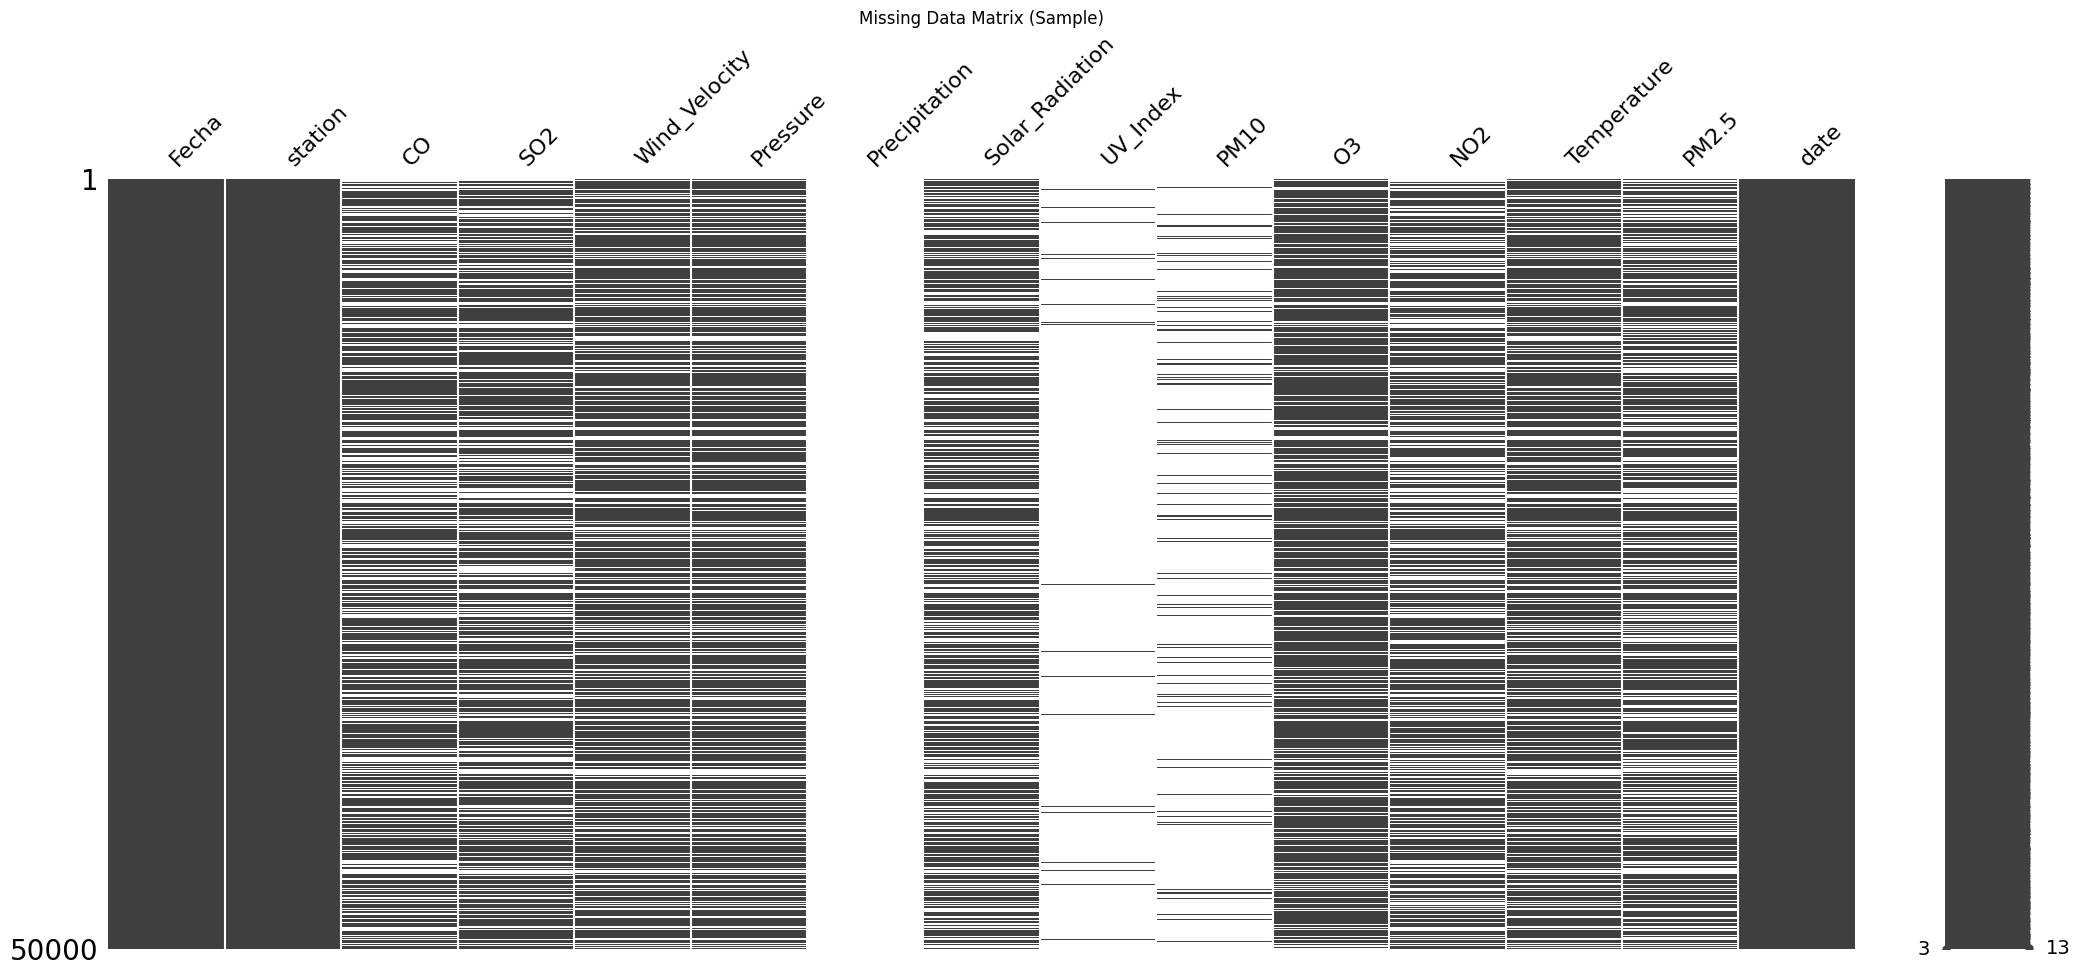

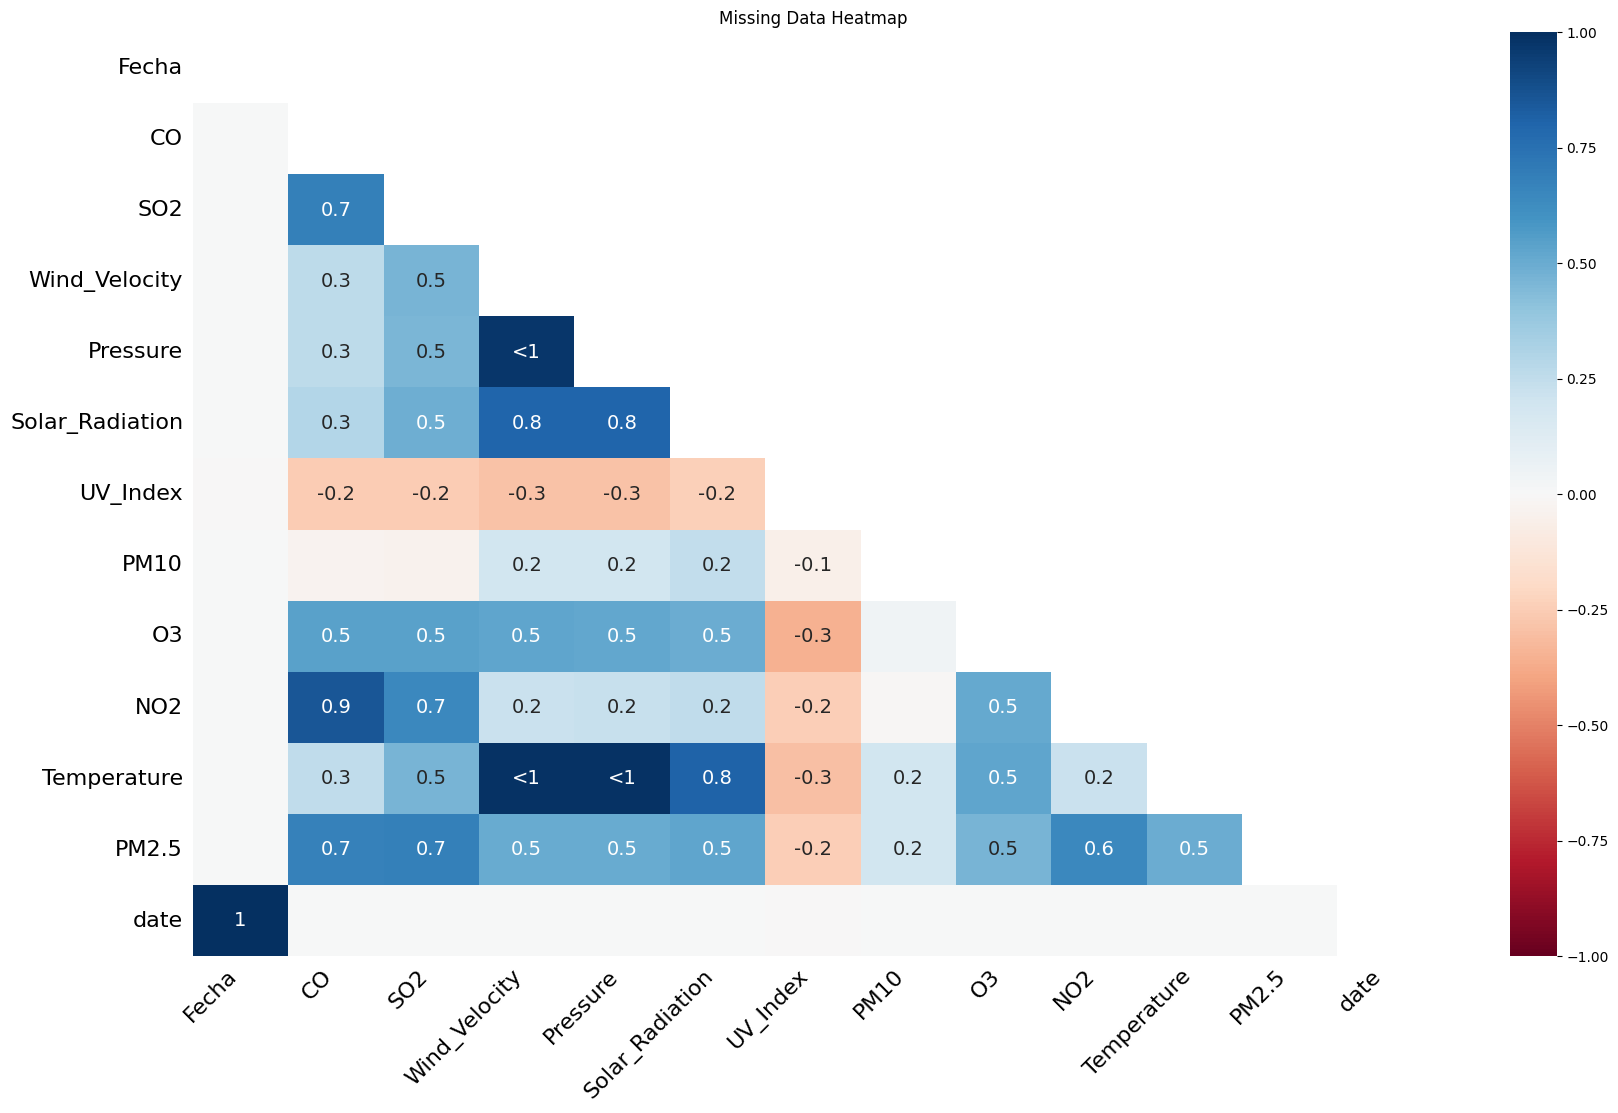

In [37]:
msno.matrix(df_master.sample(50000))  # sample para que no sea gigante
plt.title("Missing Data Matrix (Sample)")
plt.show()

msno.heatmap(df_master)
plt.title("Missing Data Heatmap")
plt.show()

In [38]:
missing_pct = df_master.isna().mean().sort_values(ascending=False)
missing_pct

Precipitation      1.000000e+00
UV_Index           9.669535e-01
PM10               8.979905e-01
Solar_Radiation    3.709249e-01
NO2                3.678852e-01
PM2.5              3.633951e-01
CO                 3.509811e-01
SO2                3.457857e-01
Wind_Velocity      2.810552e-01
Pressure           2.798806e-01
Temperature        2.773450e-01
O3                 2.156747e-01
Fecha              5.527653e-07
date               5.527653e-07
station            0.000000e+00
dtype: float64

In [39]:
df_imputed = df_master.copy()

num_cols = [
    'CO','UV_Index','Precipitation','NO2','O3',
    'PM10','PM2.5','Pressure','Solar_Radiation',
    'SO2','Temperature','Wind_Velocity'
]

# Eliminar filas sin fecha (CRÍTICO)
df_imputed = df_imputed.dropna(subset=['date'])

# Forzar columnas numéricas
for col in num_cols:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors='coerce')

# Procesar cada estación por separado
df_list = []

for station in df_imputed['station'].unique():
    # Filtrar por estación
    df_station = df_imputed[df_imputed['station'] == station].copy()
    
    # Ordenar por fecha y establecer como índice
    df_station = df_station.sort_values('date').set_index('date')
    
    # Interpolar
    df_station[num_cols] = df_station[num_cols].interpolate(method='time')
    df_station[num_cols] = df_station[num_cols].ffill().bfill()
    
    # Reset index y añadir a la lista
    df_station = df_station.reset_index()
    df_list.append(df_station)

# Concatenar todas las estaciones
df_imputed = pd.concat(df_list, ignore_index=True)

# Verificar que station se mantuvo
print(f"Columnas en df_imputed: {list(df_imputed.columns)}")
print(f"Estaciones unicas: {df_imputed['station'].nunique()}")
print(f"Total de registros: {len(df_imputed):,}")

# Verificar missing final
df_imputed.isna().mean().sort_values(ascending=False)

Columnas en df_imputed: ['date', 'Fecha', 'station', 'CO', 'SO2', 'Wind_Velocity', 'Pressure', 'Precipitation', 'Solar_Radiation', 'UV_Index', 'PM10', 'O3', 'NO2', 'Temperature', 'PM2.5']
Estaciones unicas: 10
Total de registros: 1,809,085


Precipitation      1.000000
UV_Index           0.959474
PM10               0.680174
NO2                0.147135
CO                 0.147135
SO2                0.147135
Wind_Velocity      0.040526
Solar_Radiation    0.040526
O3                 0.040526
Temperature        0.040526
Pressure           0.040526
PM2.5              0.040526
Fecha              0.000000
station            0.000000
date               0.000000
dtype: float64

In [40]:
# PASO 3: Agregacion diaria (horaria -> diaria)
log.info("Creando agregacion diaria...")

df_daily = df_imputed.groupby([pd.Grouper(key='date', freq='D'), 'station']).agg({
    'PM2.5': ['mean', 'std', 'min', 'max'],
    'Temperature': ['mean', 'min', 'max'],
    'Wind_Velocity': 'mean',
    'Precipitation': 'sum',
    'CO': 'mean',
    'NO2': 'mean',
    'O3': 'mean',
    'PM10': 'mean'
}).reset_index()

# Aplanar nombres de columnas
df_daily.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_daily.columns.values]
df_daily = df_daily.rename(columns={'date': 'Date_time'})

log.info(f"Agregacion diaria: {len(df_daily):,} registros")
log.info(f"Rango: {df_daily['Date_time'].min()} -> {df_daily['Date_time'].max()}")

df_daily.head()

[02/01/26 21:52:28] INFO     Creando agregacion diaria...                                           ]8;id=937599;file:///tmp/ipykernel_3240/3482401753.py\3482401753.py]8;;\:]8;id=735839;file:///tmp/ipykernel_3240/3482401753.py#2\2]8;;\

[02/01/26 21:52:30] INFO     Agregacion diaria: 75,388 registros                                   ]8;id=375174;file:///tmp/ipykernel_3240/3482401753.py\3482401753.py]8;;\:]8;id=731795;file:///tmp/ipykernel_3240/3482401753.py#19\19]8;;\

                    INFO     Rango: 2004-01-01 00:00:00 -> 2025-12-31 00:00:00                     ]8;id=895167;file:///tmp/ipykernel_3240/3482401753.py\3482401753.py]8;;\:]8;id=351706;file:///tmp/ipykernel_3240/3482401753.py#20\20]8;;\

,Date_time,station,PM2.5_mean,PM2.5_std,PM2.5_min,PM2.5_max,Temperature_mean,Temperature_min,Temperature_max,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,PM10_mean
0,2004-01-01,BELISARIO,27.35,0.0,27.35,27.35,14.010417,8.63,19.39,2.453750,0.0,4.510000,4.130000,64.025000,NaN
1,2004-01-01,CARAPUNGO,0.00,0.0,0.00,0.00,16.443333,11.64,23.59,3.616667,0.0,1.990000,15.250000,43.310000,52.14
2,2004-01-01,CENTRO,16.00,0.0,16.00,16.00,16.860000,16.86,16.86,1.760000,0.0,3.008333,23.655417,97.010000,NaN
3,2004-01-01,COTOCOLLAO,0.00,0.0,0.00,0.00,14.505417,9.44,21.88,1.190417,0.0,1.790000,22.210000,60.770000,NaN
4,2004-01-01,EL CAMAL,24.73,0.0,24.73,24.73,15.505000,11.08,21.39,2.521667,0.0,1.113750,16.527917,37.132917,NaN


In [41]:
# PASO 4: Agregacion mensual (para forecast 5-10 años)
log.info("Creando agregacion mensual...")

df_monthly = df_imputed.copy()
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

df_monthly = df_monthly.groupby(['year_month', 'station']).agg({
    'PM2.5': ['mean', 'std', 'min', 'max'],
    'Temperature': ['mean', 'min', 'max'],
    'Wind_Velocity': 'mean',
    'Precipitation': 'sum',
    'CO': 'mean',
    'NO2': 'mean',
    'O3': 'mean'
}).reset_index()

df_monthly.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in df_monthly.columns.values]
df_monthly['Date_time'] = df_monthly['year_month'].dt.to_timestamp()

log.info(f"Agregacion mensual: {len(df_monthly):,} registros")
log.info(f"Meses unicos: {df_monthly['Date_time'].nunique()}")

df_monthly.head()

                    INFO     Creando agregacion mensual...                                          ]8;id=431769;file:///tmp/ipykernel_3240/3028583481.py\3028583481.py]8;;\:]8;id=389296;file:///tmp/ipykernel_3240/3028583481.py#2\2]8;;\

                    INFO     Agregacion mensual: 2,477 registros                                   ]8;id=836595;file:///tmp/ipykernel_3240/3028583481.py\3028583481.py]8;;\:]8;id=106231;file:///tmp/ipykernel_3240/3028583481.py#20\20]8;;\

                    INFO     Meses unicos: 264                                                     ]8;id=393150;file:///tmp/ipykernel_3240/3028583481.py\3028583481.py]8;;\:]8;id=213246;file:///tmp/ipykernel_3240/3028583481.py#21\21]8;;\

,year_month,station,PM2.5_mean,PM2.5_std,PM2.5_min,PM2.5_max,Temperature_mean,Temperature_min,Temperature_max,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,Date_time
0,2004-01,BELISARIO,27.35,0.0,27.35,27.35,12.679012,5.29,19.95,1.742392,0.0,4.263152,4.130000,57.502829,2004-01-01
1,2004-01,CARAPUNGO,0.00,0.0,0.00,0.00,14.481405,5.74,24.07,1.946526,0.0,1.990000,15.250000,43.310000,2004-01-01
2,2004-01,CENTRO,16.00,0.0,16.00,16.00,16.860000,16.86,16.86,1.760000,0.0,3.492198,43.150766,97.010000,2004-01-01
3,2004-01,COTOCOLLAO,0.00,0.0,0.00,0.00,13.340349,5.47,22.40,1.158259,0.0,1.790000,22.210000,60.770000,2004-01-01
4,2004-01,EL CAMAL,24.73,0.0,24.73,24.73,13.539852,6.12,21.45,1.895444,0.0,1.335531,29.443763,31.437164,2004-01-01


In [42]:
# PASO 5: Crear features temporales
log.info("Generando features temporales...")

datasets = [
    ('diaria', df_daily),
    ('mensual', df_monthly)
]

for name, df in datasets:
    date_col = 'Date_time'
    
    # Features basicas de tiempo
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day_of_week'] = df[date_col].dt.dayofweek
    df['quarter'] = df[date_col].dt.quarter
    df['day_of_year'] = df[date_col].dt.dayofyear
    
    # Features ciclicas (capturan estacionalidad)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Feature numerica para regresion
    df['days_since_start'] = (df[date_col] - df[date_col].min()).dt.days
    
    log.info(f"  Dataset {name}: {len(df.columns)} columnas totales")

log.info("Features temporales creadas")

[02/01/26 21:52:31] INFO     Generando features temporales...                                       ]8;id=78690;file:///tmp/ipykernel_3240/3147340023.py\3147340023.py]8;;\:]8;id=977581;file:///tmp/ipykernel_3240/3147340023.py#2\2]8;;\

                    INFO       Dataset diaria: 23 columnas totales                                 ]8;id=382158;file:///tmp/ipykernel_3240/3147340023.py\3147340023.py]8;;\:]8;id=201858;file:///tmp/ipykernel_3240/3147340023.py#26\26]8;;\

                    INFO       Dataset mensual: 23 columnas totales                                ]8;id=418181;file:///tmp/ipykernel_3240/3147340023.py\3147340023.py]8;;\:]8;id=325827;file:///tmp/ipykernel_3240/3147340023.py#26\26]8;;\

                    INFO     Features temporales creadas                                           ]8;id=276951;file:///tmp/ipykernel_3240/3147340023.py\3147340023.py]8;;\:]8;id=654357;file:///tmp/ipykernel_3240/3147340023.py#28\28]8;;\

In [43]:
# PASO 6: Crear dataset agregado ciudad (promedio multi-estacion)
log.info("Creando dataset agregado de ciudad (promedio de todas las estaciones)...")

df_city = df_daily.groupby('Date_time').agg({
    'PM2.5_mean': 'mean',
    'PM2.5_std': 'mean',
    'Temperature_mean': 'mean',
    'Wind_Velocity_mean': 'mean',
    'Precipitation_sum': 'sum',
    'CO_mean': 'mean',
    'NO2_mean': 'mean',
    'O3_mean': 'mean',
    'PM10_mean': 'mean',
    'month_sin': 'first',
    'month_cos': 'first',
    'days_since_start': 'first'
}).reset_index()

log.info(f"Dataset ciudad: {len(df_city):,} dias")
log.info(f"Periodo: {df_city['Date_time'].min().date()} -> {df_city['Date_time'].max().date()}")

df_city.head()

                    INFO     Creando dataset agregado de ciudad (promedio de todas las              ]8;id=959461;file:///tmp/ipykernel_3240/3564746337.py\3564746337.py]8;;\:]8;id=914666;file:///tmp/ipykernel_3240/3564746337.py#2\2]8;;\
                             estaciones)...                                                                        

                    INFO     Dataset ciudad: 8,036 dias                                            ]8;id=801583;file:///tmp/ipykernel_3240/3564746337.py\3564746337.py]8;;\:]8;id=402194;file:///tmp/ipykernel_3240/3564746337.py#19\19]8;;\

                    INFO     Periodo: 2004-01-01 -> 2025-12-31                                     ]8;id=27101;file:///tmp/ipykernel_3240/3564746337.py\3564746337.py]8;;\:]8;id=788040;file:///tmp/ipykernel_3240/3564746337.py#20\20]8;;\

,Date_time,PM2.5_mean,PM2.5_std,Temperature_mean,Wind_Velocity_mean,Precipitation_sum,CO_mean,NO2_mean,O3_mean,PM10_mean,month_sin,month_cos,days_since_start
0,2004-01-01,16.082222,0.0,15.788559,2.390185,0.0,1.920260,19.747917,47.441759,37.713333,0.5,0.866025,0
1,2004-01-02,16.082222,0.0,16.040547,2.329583,0.0,1.938438,19.306823,44.156528,37.713333,0.5,0.866025,1
2,2004-01-03,16.082222,0.0,15.318213,1.844861,0.0,1.999323,21.698802,42.975556,37.713333,0.5,0.866025,2
3,2004-01-04,16.082222,0.0,15.261659,1.855556,0.0,1.934687,19.946823,46.187176,37.713333,0.5,0.866025,3
4,2004-01-05,16.082222,0.0,14.830943,1.826111,0.0,2.011354,21.745625,46.800370,37.713333,0.5,0.866025,4


In [44]:
# PASO 7: Train/Test split temporal (80/20)
log.info("Dividiendo dataset en Train/Test...")

split_date = df_city['Date_time'].quantile(0.8)
train = df_city[df_city['Date_time'] < split_date].copy()
test = df_city[df_city['Date_time'] >= split_date].copy()

log.info(f"Train: {len(train):,} dias ({train['Date_time'].min().date()} -> {train['Date_time'].max().date()})")
log.info(f"Test:  {len(test):,} dias ({test['Date_time'].min().date()} -> {test['Date_time'].max().date()})")
log.info(f"Fecha de corte: {split_date.date()}")

                    INFO     Dividiendo dataset en Train/Test...                                    ]8;id=532914;file:///tmp/ipykernel_3240/3579624166.py\3579624166.py]8;;\:]8;id=796790;file:///tmp/ipykernel_3240/3579624166.py#2\2]8;;\

                    INFO     Train: 6,428 dias (2004-01-01 -> 2021-08-06)                           ]8;id=117194;file:///tmp/ipykernel_3240/3579624166.py\3579624166.py]8;;\:]8;id=12194;file:///tmp/ipykernel_3240/3579624166.py#8\8]8;;\

                    INFO     Test:  1,608 dias (2021-08-07 -> 2025-12-31)                           ]8;id=424380;file:///tmp/ipykernel_3240/3579624166.py\3579624166.py]8;;\:]8;id=55830;file:///tmp/ipykernel_3240/3579624166.py#9\9]8;;\

                    INFO     Fecha de corte: 2021-08-07                                            ]8;id=297924;file:///tmp/ipykernel_3240/3579624166.py\3579624166.py]8;;\:]8;id=373942;file:///tmp/ipykernel_3240/3579624166.py#10\10]8;;\

In [45]:
# PASO 8: Preparar features (X) y target (y)
log.info("Preparando features y target para modelo...")

# Features seleccionadas (multivariable)
feature_cols = [
    'days_since_start',
    'Temperature_mean',
    'Wind_Velocity_mean',
    'Precipitation_sum',
    'month_sin',
    'month_cos'
]

X_train = train[feature_cols]
y_train = train['PM2.5_mean']

X_test = test[feature_cols]
y_test = test['PM2.5_mean']

log.info(f"X_train shape: {X_train.shape}")
log.info(f"X_test shape:  {X_test.shape}")
log.info(f"Features: {feature_cols}")

                    INFO     Preparando features y target para modelo...                            ]8;id=181132;file:///tmp/ipykernel_3240/2544634270.py\2544634270.py]8;;\:]8;id=147596;file:///tmp/ipykernel_3240/2544634270.py#2\2]8;;\

                    INFO     X_train shape: (6428, 6)                                              ]8;id=498330;file:///tmp/ipykernel_3240/2544634270.py\2544634270.py]8;;\:]8;id=933298;file:///tmp/ipykernel_3240/2544634270.py#20\20]8;;\

                    INFO     X_test shape:  (1608, 6)                                              ]8;id=151394;file:///tmp/ipykernel_3240/2544634270.py\2544634270.py]8;;\:]8;id=304102;file:///tmp/ipykernel_3240/2544634270.py#21\21]8;;\

                    INFO     Features: ['days_since_start', 'Temperature_mean',                    ]8;id=834650;file:///tmp/ipykernel_3240/2544634270.py\2544634270.py]8;;\:]8;id=967646;file:///tmp/ipykernel_3240/2544634270.py#22\22]8;;\
                             'Wind_Velocity_mean', 'Precipitation_sum', 'month_sin', 'month_cos']                  

In [46]:
# PASO 9: Crear features polinomiales (degree=2)
log.info("Generando features polinomiales (degree=2)...")

poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

log.info(f"Features originales: {X_train.shape[1]}")
log.info(f"Features polinomiales: {X_train_poly.shape[1]}")
log.info(f"Incluye: terminos lineales, cuadraticos e interacciones")

                    INFO     Generando features polinomiales (degree=2)...                          ]8;id=695508;file:///tmp/ipykernel_3240/4100187912.py\4100187912.py]8;;\:]8;id=877607;file:///tmp/ipykernel_3240/4100187912.py#2\2]8;;\

                    INFO     Features originales: 6                                                 ]8;id=364884;file:///tmp/ipykernel_3240/4100187912.py\4100187912.py]8;;\:]8;id=804718;file:///tmp/ipykernel_3240/4100187912.py#8\8]8;;\

                    INFO     Features polinomiales: 28                                              ]8;id=190189;file:///tmp/ipykernel_3240/4100187912.py\4100187912.py]8;;\:]8;id=204888;file:///tmp/ipykernel_3240/4100187912.py#9\9]8;;\

                    INFO     Incluye: terminos lineales, cuadraticos e interacciones               ]8;id=197214;file:///tmp/ipykernel_3240/4100187912.py\4100187912.py]8;;\:]8;id=854065;file:///tmp/ipykernel_3240/4100187912.py#10\10]8;;\

In [47]:
# PASO 10: Escalado de features
log.info("Aplicando escalado a features polinomiales...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

log.info(f"Escalado aplicado: media=0, std=1")
log.info(f"Scaler guardado para reproducibilidad")

# Guardar scaler para uso futuro
with open('scaler_model1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

                    INFO     Aplicando escalado a features polinomiales...                          ]8;id=156176;file:///tmp/ipykernel_3240/1567515665.py\1567515665.py]8;;\:]8;id=906264;file:///tmp/ipykernel_3240/1567515665.py#2\2]8;;\

                    INFO     Escalado aplicado: media=0, std=1                                      ]8;id=701077;file:///tmp/ipykernel_3240/1567515665.py\1567515665.py]8;;\:]8;id=346025;file:///tmp/ipykernel_3240/1567515665.py#8\8]8;;\

                    INFO     Scaler guardado para reproducibilidad                                  ]8;id=964319;file:///tmp/ipykernel_3240/1567515665.py\1567515665.py]8;;\:]8;id=312631;file:///tmp/ipykernel_3240/1567515665.py#9\9]8;;\

In [48]:
# PASO 11: Entrenar modelo de Regresion Lineal
log.info("Entrenando modelo de Regresion Cuadratica...")

start_time = time.time()
model_quad = LinearRegression()
model_quad.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

log.info(f"Modelo entrenado en {training_time:.3f} segundos")
log.info(f"Coeficientes: {len(model_quad.coef_)} features")
log.info(f"Intercepto: {model_quad.intercept_:.4f}")

                    INFO     Entrenando modelo de Regresion Cuadratica...                           ]8;id=126672;file:///tmp/ipykernel_3240/3198767363.py\3198767363.py]8;;\:]8;id=254109;file:///tmp/ipykernel_3240/3198767363.py#2\2]8;;\

                    INFO     Modelo entrenado en 0.052 segundos                                     ]8;id=722811;file:///tmp/ipykernel_3240/3198767363.py\3198767363.py]8;;\:]8;id=664641;file:///tmp/ipykernel_3240/3198767363.py#9\9]8;;\

                    INFO     Coeficientes: 28 features                                             ]8;id=984130;file:///tmp/ipykernel_3240/3198767363.py\3198767363.py]8;;\:]8;id=615687;file:///tmp/ipykernel_3240/3198767363.py#10\10]8;;\

                    INFO     Intercepto: 17.6438                                                   ]8;id=225213;file:///tmp/ipykernel_3240/3198767363.py\3198767363.py]8;;\:]8;id=823766;file:///tmp/ipykernel_3240/3198767363.py#11\11]8;;\

In [49]:
# PASO 12: Generar predicciones
log.info("Generando predicciones...")

y_pred_train = model_quad.predict(X_train_scaled)
y_pred_test = model_quad.predict(X_test_scaled)

log.info(f"Train - Real: [{y_train.min():.2f}, {y_train.max():.2f}] | Pred: [{y_pred_train.min():.2f}, {y_pred_train.max():.2f}]")
log.info(f"Test  - Real: [{y_test.min():.2f}, {y_test.max():.2f}] | Pred: [{y_pred_test.min():.2f}, {y_pred_test.max():.2f}]")

                    INFO     Generando predicciones...                                              ]8;id=907564;file:///tmp/ipykernel_3240/3705531652.py\3705531652.py]8;;\:]8;id=135459;file:///tmp/ipykernel_3240/3705531652.py#2\2]8;;\

                    INFO     Train - Real: [5.04, 35.59] | Pred: [6.98, 23.45]                      ]8;id=165998;file:///tmp/ipykernel_3240/3705531652.py\3705531652.py]8;;\:]8;id=824713;file:///tmp/ipykernel_3240/3705531652.py#7\7]8;;\

                    INFO     Test  - Real: [5.79, 37.07] | Pred: [-1.07, 17.50]                     ]8;id=776089;file:///tmp/ipykernel_3240/3705531652.py\3705531652.py]8;;\:]8;id=243445;file:///tmp/ipykernel_3240/3705531652.py#8\8]8;;\

In [50]:
# PASO 13: Calcular metricas de evaluacion
log.info("Calculando metricas de evaluacion...")

metrics = {
    'train': {
        'MSE': mean_squared_error(y_train, y_pred_train),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'MAE': mean_absolute_error(y_train, y_pred_train),
        'R2': r2_score(y_train, y_pred_train)
    },
    'test': {
        'MSE': mean_squared_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'R2': r2_score(y_test, y_pred_test)
    }
}

print("\n" + "="*60)
print("METRICAS DEL MODELO 1: REGRESION CUADRATICA")
print("="*60)
print(f"\n{'Metrica':<10} {'Train':>12} {'Test':>12}")
print("-"*60)
for metric in ['MSE', 'RMSE', 'MAE', 'R2']:
    print(f"{metric:<10} {metrics['train'][metric]:>12.4f} {metrics['test'][metric]:>12.4f}")
print("="*60)

                    INFO     Calculando metricas de evaluacion...                                    ]8;id=477531;file:///tmp/ipykernel_3240/243852550.py\243852550.py]8;;\:]8;id=940673;file:///tmp/ipykernel_3240/243852550.py#2\2]8;;\


METRICAS DEL MODELO 1: REGRESION CUADRATICA

Metrica           Train         Test
------------------------------------------------------------
MSE              9.1305      74.8925
RMSE             3.0217       8.6540
MAE              2.3040       7.5185
R2               0.3888      -3.2855


                    INFO     Generando visualizacion: Timeline completo...                           ]8;id=410771;file:///tmp/ipykernel_3240/868743804.py\868743804.py]8;;\:]8;id=104722;file:///tmp/ipykernel_3240/868743804.py#2\2]8;;\

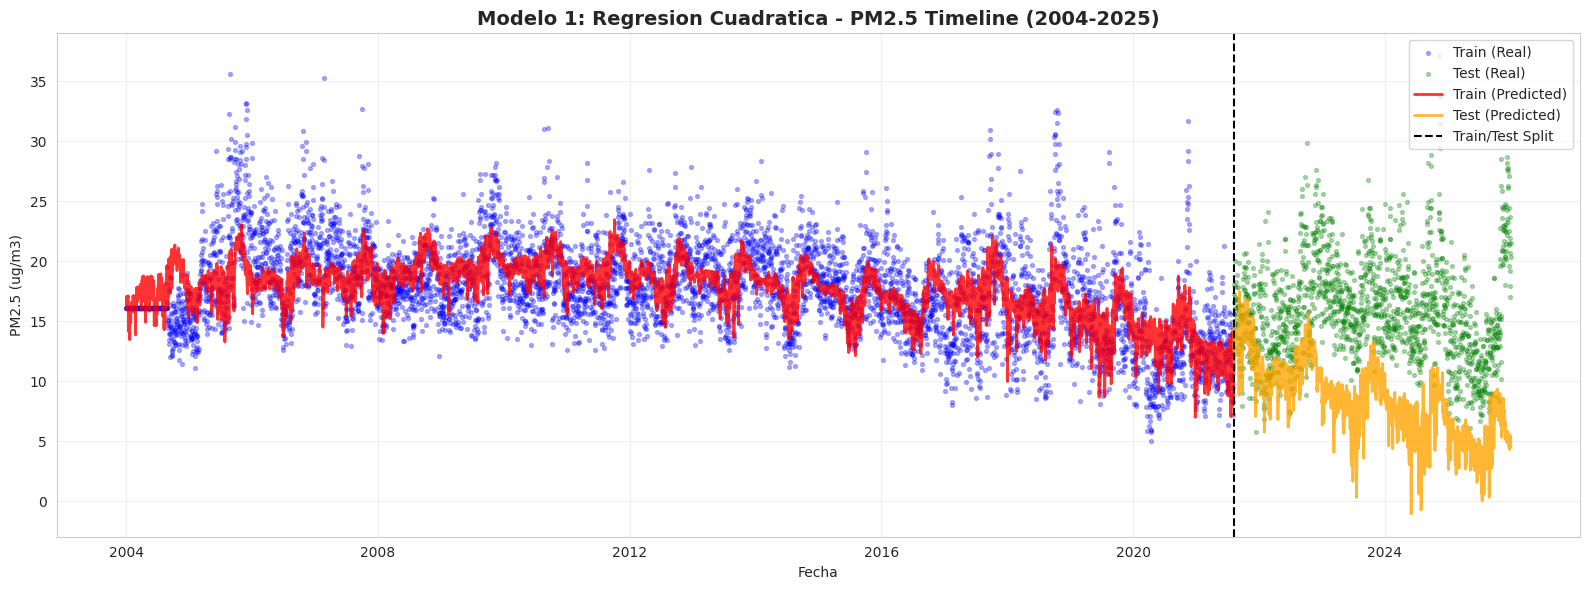

[02/01/26 21:52:32] INFO     Guardado: model1_timeline.png                                          ]8;id=869452;file:///tmp/ipykernel_3240/868743804.py\868743804.py]8;;\:]8;id=298046;file:///tmp/ipykernel_3240/868743804.py#22\22]8;;\

In [51]:
# PASO 14: Visualizacion 1 - Timeline completo
log.info("Generando visualizacion: Timeline completo...")

sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

plt.scatter(train['Date_time'], y_train, alpha=0.3, s=8, label='Train (Real)', color='blue')
plt.scatter(test['Date_time'], y_test, alpha=0.3, s=8, label='Test (Real)', color='green')
plt.plot(train['Date_time'], y_pred_train, color='red', label='Train (Predicted)', linewidth=2, alpha=0.8)
plt.plot(test['Date_time'], y_pred_test, color='orange', label='Test (Predicted)', linewidth=2, alpha=0.8)
plt.axvline(split_date, color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')

plt.title('Modelo 1: Regresion Cuadratica - PM2.5 Timeline (2004-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model1_timeline.png', dpi=150)
plt.show()

log.info("Guardado: model1_timeline.png")

                    INFO     Generando visualizacion: Residual Plot...                               ]8;id=650670;file:///tmp/ipykernel_3240/440198764.py\440198764.py]8;;\:]8;id=661217;file:///tmp/ipykernel_3240/440198764.py#2\2]8;;\

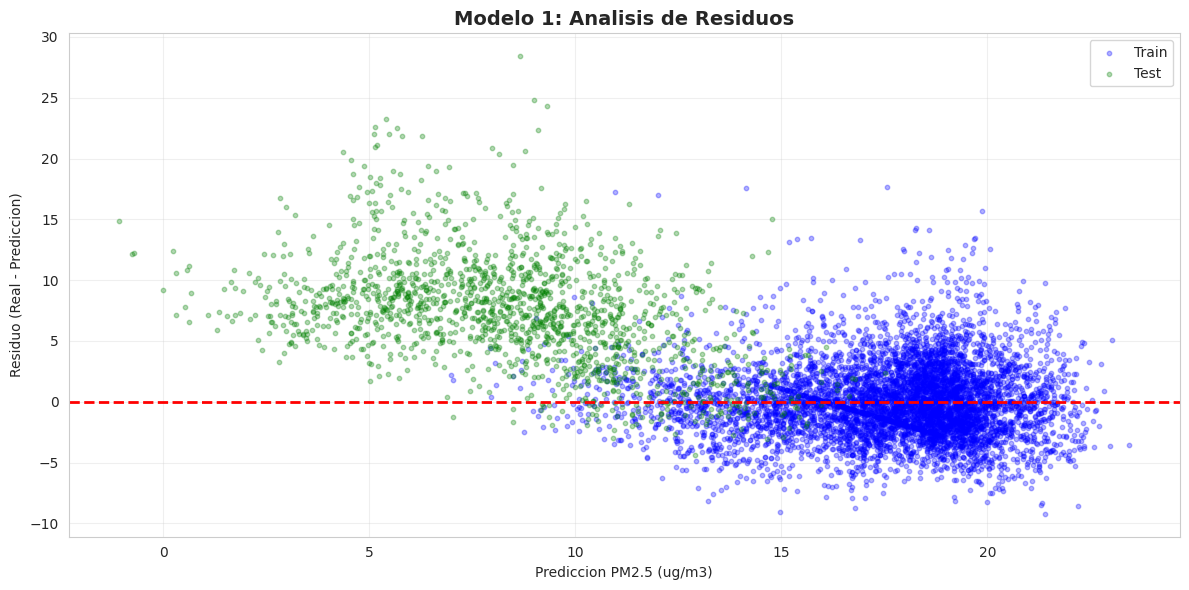

[02/01/26 21:52:33] INFO     Residuos centrados en 0 indican buen ajuste                            ]8;id=467590;file:///tmp/ipykernel_3240/440198764.py\440198764.py]8;;\:]8;id=390719;file:///tmp/ipykernel_3240/440198764.py#20\20]8;;\

In [52]:
# PASO 15: Visualizacion 2 - Residual Plot
log.info("Generando visualizacion: Residual Plot...")

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

plt.figure(figsize=(12, 6))
plt.scatter(y_pred_train, residuals_train, alpha=0.3, s=10, label='Train', color='blue')
plt.scatter(y_pred_test, residuals_test, alpha=0.3, s=10, label='Test', color='green')
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title('Modelo 1: Analisis de Residuos', fontsize=14, fontweight='bold')
plt.xlabel('Prediccion PM2.5 (ug/m3)')
plt.ylabel('Residuo (Real - Prediccion)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

log.info("Residuos centrados en 0 indican buen ajuste")

                    INFO     Generando visualizacion: Real vs Predicted...                           ]8;id=626704;file:///tmp/ipykernel_3240/554348750.py\554348750.py]8;;\:]8;id=538710;file:///tmp/ipykernel_3240/554348750.py#2\2]8;;\

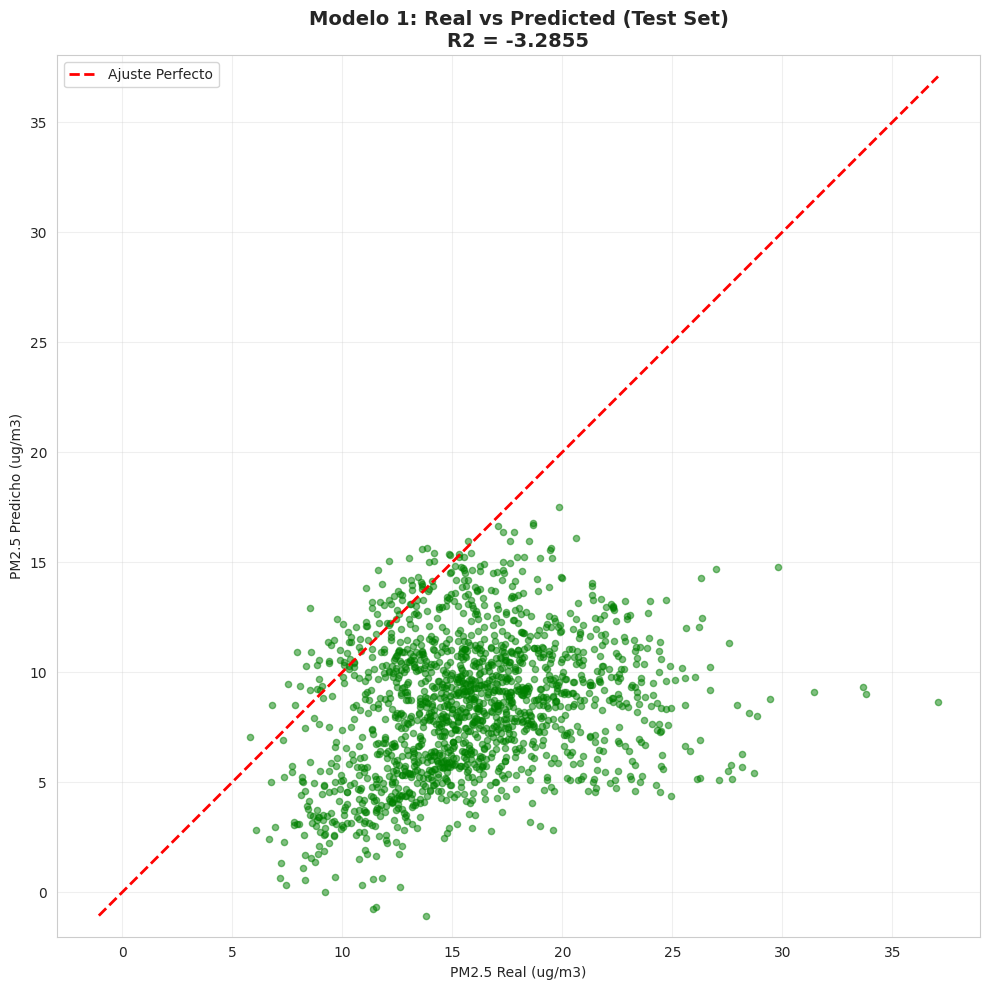

                    INFO     Guardado: model1_scatter.png                                           ]8;id=23554;file:///tmp/ipykernel_3240/554348750.py\554348750.py]8;;\:]8;id=774229;file:///tmp/ipykernel_3240/554348750.py#22\22]8;;\

In [53]:
# PASO 16: Visualizacion 3 - Real vs Predicted
log.info("Generando visualizacion: Real vs Predicted...")

plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=20, color='green')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste Perfecto')

plt.title(f'Modelo 1: Real vs Predicted (Test Set)\nR2 = {metrics["test"]["R2"]:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 Real (ug/m3)')
plt.ylabel('PM2.5 Predicho (ug/m3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig('model1_scatter.png', dpi=150)
plt.show()

log.info("Guardado: model1_scatter.png")

                    INFO     Generando visualizacion: Distribucion de errores...                      ]8;id=284312;file:///tmp/ipykernel_3240/86995909.py\86995909.py]8;;\:]8;id=390282;file:///tmp/ipykernel_3240/86995909.py#2\2]8;;\

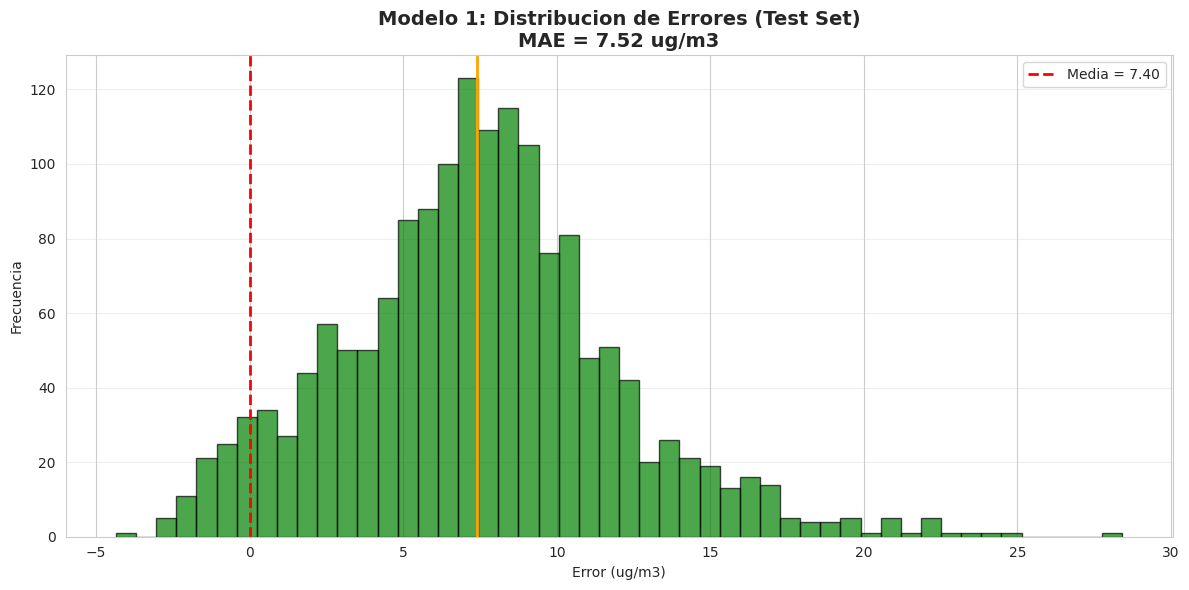

[02/01/26 21:52:34] INFO     Distribucion normal de errores indica supuestos de regresion validos    ]8;id=83573;file:///tmp/ipykernel_3240/86995909.py\86995909.py]8;;\:]8;id=105211;file:///tmp/ipykernel_3240/86995909.py#18\18]8;;\

In [54]:
# PASO 17: Visualizacion 4 - Distribucion de errores
log.info("Generando visualizacion: Distribucion de errores...")

plt.figure(figsize=(12, 6))
plt.hist(residuals_test, bins=50, alpha=0.7, color='green', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Media = {residuals_test.mean():.2f}')
plt.axvline(residuals_test.mean(), color='orange', linestyle='-', linewidth=2)

plt.title(f'Modelo 1: Distribucion de Errores (Test Set)\nMAE = {metrics["test"]["MAE"]:.2f} ug/m3', 
          fontsize=14, fontweight='bold')
plt.xlabel('Error (ug/m3)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

log.info("Distribucion normal de errores indica supuestos de regresion validos")

                    INFO     Analizando importancia de features...                                  ]8;id=435748;file:///tmp/ipykernel_3240/4262455548.py\4262455548.py]8;;\:]8;id=957661;file:///tmp/ipykernel_3240/4262455548.py#2\2]8;;\

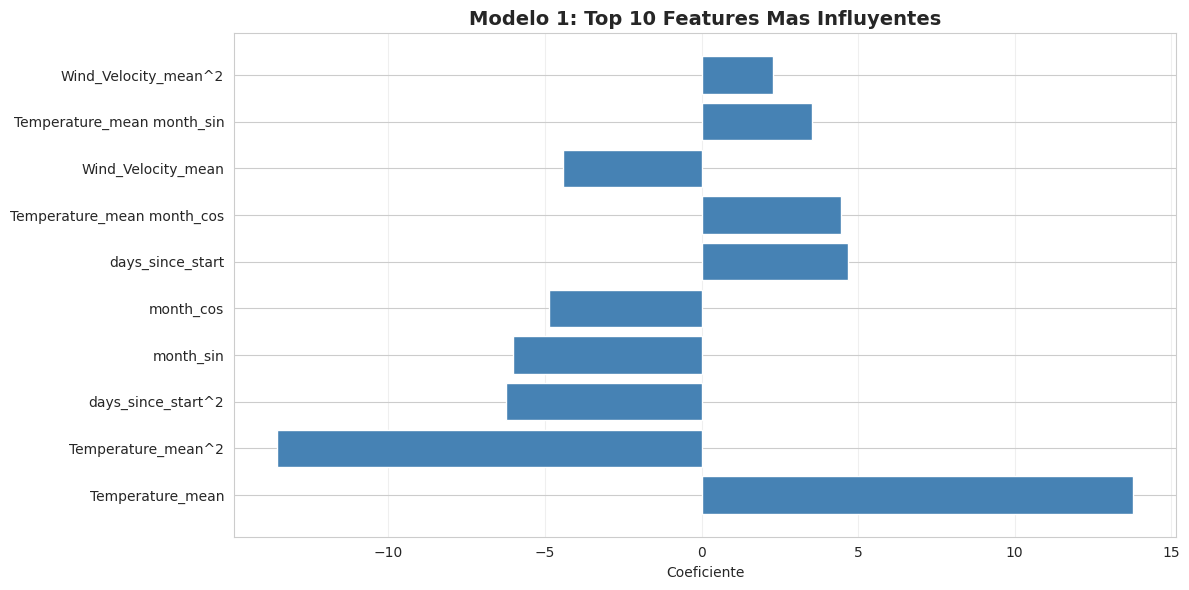

                    INFO     Feature mas influyente: Temperature_mean                              ]8;id=302151;file:///tmp/ipykernel_3240/4262455548.py\4262455548.py]8;;\:]8;id=408920;file:///tmp/ipykernel_3240/4262455548.py#26\26]8;;\

In [55]:
# PASO 18: Analisis de Feature Importance
log.info("Analizando importancia de features...")

feature_names = poly.get_feature_names_out(feature_cols)
coefficients = model_quad.coef_

# Crear DataFrame de coeficientes
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coefficients,
    'Abs_Coef': np.abs(coefficients)
}).sort_values('Abs_Coef', ascending=False)

# Top 10 features mas importantes
top_features = coef_df.head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features)), top_features['Coeficiente'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coeficiente')
plt.title('Modelo 1: Top 10 Features Mas Influyentes', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

log.info(f"Feature mas influyente: {top_features.iloc[0]['Feature']}")

In [56]:
# PASO 19: Exportar resultados del modelo
log.info("Exportando resultados del Modelo 1...")

# Guardar modelo y transformadores
model1_artifacts = {
    'model': model_quad,
    'poly_transformer': poly,
    'scaler': scaler,
    'feature_columns': feature_cols
}

with open('model1_artifacts.pkl', 'wb') as f:
    pickle.dump(model1_artifacts, f)

# Guardar metricas en JSON
metrics_export = {
    'model_name': 'Modelo 1: Regresion Cuadratica Multivariable',
    'model_type': 'Polynomial Regression (degree=2)',
    'features': feature_cols,
    'n_polynomial_features': X_train_poly.shape[1],
    'metrics': metrics,
    'training_data_size': len(train),
    'test_data_size': len(test)
}

with open('model1_metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)

log.info("Guardado: model1_artifacts.pkl")
log.info("Guardado: model1_metrics.json")
log.info("Archivos listos para comparacion con otros modelos")

[02/01/26 21:52:36] INFO     Exportando resultados del Modelo 1...                                  ]8;id=815222;file:///tmp/ipykernel_3240/3637314873.py\3637314873.py]8;;\:]8;id=446542;file:///tmp/ipykernel_3240/3637314873.py#2\2]8;;\

                    INFO     Guardado: model1_artifacts.pkl                                        ]8;id=127358;file:///tmp/ipykernel_3240/3637314873.py\3637314873.py]8;;\:]8;id=412044;file:///tmp/ipykernel_3240/3637314873.py#29\29]8;;\

                    INFO     Guardado: model1_metrics.json                                         ]8;id=829006;file:///tmp/ipykernel_3240/3637314873.py\3637314873.py]8;;\:]8;id=803217;file:///tmp/ipykernel_3240/3637314873.py#30\30]8;;\

                    INFO     Archivos listos para comparacion con otros modelos                    ]8;id=271180;file:///tmp/ipykernel_3240/3637314873.py\3637314873.py]8;;\:]8;id=285621;file:///tmp/ipykernel_3240/3637314873.py#31\31]8;;\

In [58]:
# PASO 20: Summary Report - Modelo 1
log.info("="*60)
log.info("REPORTE FINAL - MODELO 1: REGRESION CUADRATICA")
log.info("="*60)

print(f"\nCONFIGURACION DEL MODELO:")
print(f"  - Tipo: Regresion Polinomial (degree=2)")
print(f"  - Features originales: {len(feature_cols)}")
print(f"  - Features polinomiales: {X_train_poly.shape[1]}")
print(f"  - Escalado: StandardScaler aplicado")

print(f"\nPERFORMANCE (TEST SET):")
print(f"  - RMSE: {metrics['test']['RMSE']:.2f} ug/m3")
print(f"  - MAE:  {metrics['test']['MAE']:.2f} ug/m3")
print(f"  - R2:   {metrics['test']['R2']:.4f}")

print(f"\nINTERPRETACION:")
if metrics['test']['R2'] > 0.7:
    print(f"  - Buen ajuste (R2 > 0.7)")
elif metrics['test']['R2'] > 0.5:
    print(f"  - Ajuste moderado (R2 > 0.5)")
else:
    print(f"  - Ajuste debil - considerar features adicionales")

print(f"\nENTREGABLES GENERADOS:")
print(f"  - Graficos: model1_timeline.png, model1_scatter.png")
print(f"  - Artefactos: model1_artifacts.pkl")
print(f"  - Metricas: model1_metrics.json")

print(f"\nPROXIMOS PASOS:")
print(f"  - Comparar con modelos ARIMA, LSTM, MLForecast")
print(f"  - Validar con datos futuros (2026+)")
print(f"  - Considerar mejoras: features adicionales, regularizacion")

log.info("="*60)
log.info("Modelo 1 completado exitosamente")
log.info("="*60)

[02/01/26 21:52:43] INFO     ============================================================           ]8;id=452615;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=181858;file:///tmp/ipykernel_3240/2462877711.py#2\2]8;;\

                    INFO     REPORTE FINAL - MODELO 1: REGRESION CUADRATICA                         ]8;id=753445;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=910864;file:///tmp/ipykernel_3240/2462877711.py#3\3]8;;\

                    INFO     ============================================================           ]8;id=269326;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=299201;file:///tmp/ipykernel_3240/2462877711.py#4\4]8;;\


CONFIGURACION DEL MODELO:
  - Tipo: Regresion Polinomial (degree=2)
  - Features originales: 6
  - Features polinomiales: 28
  - Escalado: StandardScaler aplicado

PERFORMANCE (TEST SET):
  - RMSE: 8.65 ug/m3
  - MAE:  7.52 ug/m3
  - R2:   -3.2855

INTERPRETACION:
  - Ajuste debil - considerar features adicionales

ENTREGABLES GENERADOS:
  - Graficos: model1_timeline.png, model1_scatter.png
  - Artefactos: model1_artifacts.pkl
  - Metricas: model1_metrics.json

PROXIMOS PASOS:
  - Comparar con modelos ARIMA, LSTM, MLForecast
  - Validar con datos futuros (2026+)
  - Considerar mejoras: features adicionales, regularizacion


                    INFO     ============================================================          ]8;id=121347;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=270235;file:///tmp/ipykernel_3240/2462877711.py#35\35]8;;\

                    INFO     Modelo 1 completado exitosamente                                      ]8;id=781726;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=610634;file:///tmp/ipykernel_3240/2462877711.py#36\36]8;;\

                    INFO     ============================================================          ]8;id=301496;file:///tmp/ipykernel_3240/2462877711.py\2462877711.py]8;;\:]8;id=314772;file:///tmp/ipykernel_3240/2462877711.py#37\37]8;;\

# Modelo 2: Regresión Cuadrática con Gradient Descent (Implementación desde cero)

---

En esta sección implementamos Gradient Descent **desde cero** para ajustar una regresión cuadrática:

$$\hat{y} = a_0 + a_1 \cdot x + a_2 \cdot x^2$$

**Función de costo (MSE):**

$$J(a_0, a_1, a_2) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Gradientes:**

$$\frac{\partial J}{\partial a_0} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

$$\frac{\partial J}{\partial a_1} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_i$$

$$\frac{\partial J}{\partial a_2} = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot x_i^2$$

**Actualización de parámetros:**

$$a_j := a_j - \alpha \cdot \frac{\partial J}{\partial a_j}$$

donde $\alpha$ es el learning rate.

In [59]:
# MODELO 2 - PASO 1: Preparar datos para GD (solo usar days_since_start como feature)
log.info("="*60)
log.info("MODELO 2: GRADIENT DESCENT DESDE CERO")
log.info("="*60)

# Usaremos solo 'days_since_start' como feature principal para regresion cuadratica
# y = a0 + a1*x + a2*x^2

X_train_gd = train['days_since_start'].values.reshape(-1, 1)
y_train_gd = train['PM2.5_mean'].values

X_test_gd = test['days_since_start'].values.reshape(-1, 1)
y_test_gd = test['PM2.5_mean'].values

# Normalizar features (importante para convergencia rapida)
from sklearn.preprocessing import StandardScaler

scaler_gd = StandardScaler()
X_train_gd_scaled = scaler_gd.fit_transform(X_train_gd)
X_test_gd_scaled = scaler_gd.transform(X_test_gd)

log.info(f"Datos preparados para Gradient Descent")
log.info(f"Train: {len(X_train_gd)} muestras")
log.info(f"Test:  {len(X_test_gd)} muestras")
log.info(f"Feature: days_since_start (normalizada)")

[02/01/26 21:52:47] INFO     ============================================================           ]8;id=94415;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=765057;file:///tmp/ipykernel_3240/2874051401.py#2\2]8;;\

                    INFO     MODELO 2: GRADIENT DESCENT DESDE CERO                                  ]8;id=613520;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=236431;file:///tmp/ipykernel_3240/2874051401.py#3\3]8;;\

                    INFO     ============================================================           ]8;id=539633;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=969707;file:///tmp/ipykernel_3240/2874051401.py#4\4]8;;\

                    INFO     Datos preparados para Gradient Descent                                ]8;id=367004;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=413270;file:///tmp/ipykernel_3240/2874051401.py#22\22]8;;\

                    INFO     Train: 6428 muestras                                                  ]8;id=719307;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=187835;file:///tmp/ipykernel_3240/2874051401.py#23\23]8;;\

                    INFO     Test:  1608 muestras                                                  ]8;id=35986;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=704714;file:///tmp/ipykernel_3240/2874051401.py#24\24]8;;\

                    INFO     Feature: days_since_start (normalizada)                               ]8;id=149349;file:///tmp/ipykernel_3240/2874051401.py\2874051401.py]8;;\:]8;id=247183;file:///tmp/ipykernel_3240/2874051401.py#25\25]8;;\

In [60]:
# MODELO 2 - PASO 2: Implementacion de Gradient Descent desde cero

class QuadraticGradientDescent:
    """
    Implementacion desde cero de Gradient Descent para regresion cuadratica.
    Modelo: y = a0 + a1*x + a2*x^2
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=True):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        
        # Parametros del modelo
        self.a0 = 0.0  # Intercepto
        self.a1 = 0.0  # Coeficiente lineal
        self.a2 = 0.0  # Coeficiente cuadratico
        
        # Historial de entrenamiento
        self.loss_history = []
        self.params_history = []
        
    def _compute_predictions(self, X):
        """Calcula predicciones: y_hat = a0 + a1*x + a2*x^2"""
        X_flat = X.flatten()
        return self.a0 + self.a1 * X_flat + self.a2 * (X_flat ** 2)
    
    def _compute_mse(self, y_true, y_pred):
        """Calcula Mean Squared Error"""
        return np.mean((y_true - y_pred) ** 2)
    
    def _compute_gradients(self, X, y, y_pred):
        """
        Calcula gradientes de la funcion de costo MSE.
        
        Gradientes:
        dJ/da0 = -2/n * sum(y - y_hat)
        dJ/da1 = -2/n * sum((y - y_hat) * x)
        dJ/da2 = -2/n * sum((y - y_hat) * x^2)
        """
        n = len(y)
        X_flat = X.flatten()
        residuals = y - y_pred
        
        grad_a0 = -2 / n * np.sum(residuals)
        grad_a1 = -2 / n * np.sum(residuals * X_flat)
        grad_a2 = -2 / n * np.sum(residuals * (X_flat ** 2))
        
        return grad_a0, grad_a1, grad_a2
    
    def fit(self, X, y):
        """
        Entrena el modelo usando Gradient Descent.
        
        Args:
            X: Features (n_samples, 1)
            y: Target values (n_samples,)
        """
        # Inicializar parametros aleatoriamente (mejora convergencia)
        np.random.seed(42)
        self.a0 = np.random.randn() * 0.01
        self.a1 = np.random.randn() * 0.01
        self.a2 = np.random.randn() * 0.01
        
        if self.verbose:
            log.info(f"Iniciando Gradient Descent:")
            log.info(f"  Learning rate: {self.learning_rate}")
            log.info(f"  Iteraciones: {self.n_iterations}")
        
        # Gradient Descent loop
        for iteration in range(self.n_iterations):
            # 1. Calcular predicciones
            y_pred = self._compute_predictions(X)
            
            # 2. Calcular loss (MSE)
            loss = self._compute_mse(y, y_pred)
            self.loss_history.append(loss)
            
            # 3. Calcular gradientes
            grad_a0, grad_a1, grad_a2 = self._compute_gradients(X, y, y_pred)
            
            # 4. Actualizar parametros
            self.a0 -= self.learning_rate * grad_a0
            self.a1 -= self.learning_rate * grad_a1
            self.a2 -= self.learning_rate * grad_a2
            
            # 5. Guardar parametros
            self.params_history.append({
                'a0': self.a0,
                'a1': self.a1,
                'a2': self.a2
            })
            
            # 6. Logging periodico
            if self.verbose and (iteration % 100 == 0 or iteration == self.n_iterations - 1):
                log.info(f"  Iter {iteration:4d}: Loss = {loss:.4f} | a0={self.a0:.4f}, a1={self.a1:.4f}, a2={self.a2:.4f}")
        
        if self.verbose:
            log.info(f"Entrenamiento completado!")
            log.info(f"  Loss final: {self.loss_history[-1]:.4f}")
        
        return self
    
    def predict(self, X):
        """Genera predicciones para nuevos datos"""
        return self._compute_predictions(X)
    
    def score(self, X, y):
        """Calcula R-squared"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - (ss_res / ss_tot)

log.info("Clase QuadraticGradientDescent implementada exitosamente")

[02/01/26 21:52:52] INFO     Clase QuadraticGradientDescent implementada exitosamente              ]8;id=224246;file:///tmp/ipykernel_3240/162210660.py\162210660.py]8;;\:]8;id=610467;file:///tmp/ipykernel_3240/162210660.py#115\115]8;;\

In [61]:
# MODELO 2 - PASO 3: Entrenar modelo con Gradient Descent
log.info("Entrenando Modelo 2 con Gradient Descent...")

# Hiperparametros optimizados para convergencia
model_gd = QuadraticGradientDescent(
    learning_rate=0.1,
    n_iterations=2000,
    verbose=True
)

# Entrenar
start_time = time.time()
model_gd.fit(X_train_gd_scaled, y_train_gd)
training_time = time.time() - start_time

log.info(f"Tiempo de entrenamiento: {training_time:.3f} segundos")
log.info(f"Parametros finales:")
log.info(f"  a0 (intercepto): {model_gd.a0:.6f}")
log.info(f"  a1 (lineal):     {model_gd.a1:.6f}")
log.info(f"  a2 (cuadratico): {model_gd.a2:.6f}")

[02/01/26 21:52:54] INFO     Entrenando Modelo 2 con Gradient Descent...                            ]8;id=141644;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=867953;file:///tmp/ipykernel_3240/2520187644.py#2\2]8;;\

                    INFO     Iniciando Gradient Descent:                                            ]8;id=644924;file:///tmp/ipykernel_3240/162210660.py\162210660.py]8;;\:]8;id=98409;file:///tmp/ipykernel_3240/162210660.py#66\66]8;;\

                    INFO       Learning rate: 0.1                                                   ]8;id=117800;file:///tmp/ipykernel_3240/162210660.py\162210660.py]8;;\:]8;id=549478;file:///tmp/ipykernel_3240/162210660.py#67\67]8;;\

                    INFO       Iteraciones: 2000                                                    ]8;id=104351;file:///tmp/ipykernel_3240/162210660.py\162210660.py]8;;\:]8;id=266738;file:///tmp/ipykernel_3240/162210660.py#68\68]8;;\

                    INFO       Iter    0: Loss = 325.8486 | a0=3.5314, a1=-0.2831, a2=3.3189        ]8;id=513984;file:///tmp/ipykernel_3240/162210660.py\162210660.py]8;;\:]8;id=466186;file:///tmp/ipykernel_3240/162210660.py#96\96]8;;\

...

                    INFO     Tiempo de entrenamiento: 0.449 segundos                               ]8;id=643836;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=162340;file:///tmp/ipykernel_3240/2520187644.py#16\16]8;;\

                    INFO     Parametros finales:                                                   ]8;id=291816;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=80620;file:///tmp/ipykernel_3240/2520187644.py#17\17]8;;\

                    INFO       a0 (intercepto): 18.975271                                          ]8;id=251725;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=857504;file:///tmp/ipykernel_3240/2520187644.py#18\18]8;;\

                    INFO       a1 (lineal):     -1.409829                                          ]8;id=236845;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=594932;file:///tmp/ipykernel_3240/2520187644.py#19\19]8;;\

                    INFO       a2 (cuadratico): -1.331466                                          ]8;id=812332;file:///tmp/ipykernel_3240/2520187644.py\2520187644.py]8;;\:]8;id=966382;file:///tmp/ipykernel_3240/2520187644.py#20\20]8;;\

In [63]:
# MODELO 2 - PASO 4: Generar predicciones y calcular metricas
log.info("Generando predicciones para Modelo 2...")

y_pred_train_gd = model_gd.predict(X_train_gd_scaled)
y_pred_test_gd = model_gd.predict(X_test_gd_scaled)

# Calcular metricas
metrics_gd = {
    'train': {
        'MSE': mean_squared_error(y_train_gd, y_pred_train_gd),
        'RMSE': np.sqrt(mean_squared_error(y_train_gd, y_pred_train_gd)),
        'MAE': mean_absolute_error(y_train_gd, y_pred_train_gd),
        'R2': r2_score(y_train_gd, y_pred_train_gd)
    },
    'test': {
        'MSE': mean_squared_error(y_test_gd, y_pred_test_gd),
        'RMSE': np.sqrt(mean_squared_error(y_test_gd, y_pred_test_gd)),
        'MAE': mean_absolute_error(y_test_gd, y_pred_test_gd),
        'R2': r2_score(y_test_gd, y_pred_test_gd)
    }
}

print("\n" + "="*60)
print("METRICAS DEL MODELO 2: GRADIENT DESCENT (FROM SCRATCH)")
print("="*60)
print(f"\n{'Metrica':<10} {'Train':>12} {'Test':>12}")
print("-"*60)
for metric in ['MSE', 'RMSE', 'MAE', 'R2']:
    print(f"{metric:<10} {metrics_gd['train'][metric]:>12.4f} {metrics_gd['test'][metric]:>12.4f}")
print("="*60)

[02/01/26 21:53:03] INFO     Generando predicciones para Modelo 2...                                ]8;id=14265;file:///tmp/ipykernel_3240/2381776104.py\2381776104.py]8;;\:]8;id=394017;file:///tmp/ipykernel_3240/2381776104.py#2\2]8;;\


METRICAS DEL MODELO 2: GRADIENT DESCENT (FROM SCRATCH)

Metrica           Train         Test
------------------------------------------------------------
MSE             11.5327      59.3056
RMSE             3.3960       7.7010
MAE              2.6318       6.4387
R2               0.2280      -2.3936


[02/01/26 21:53:06] INFO     Generando visualizacion: Evolucion del Loss durante Gradient           ]8;id=6593;file:///tmp/ipykernel_3240/2138558168.py\2138558168.py]8;;\:]8;id=794834;file:///tmp/ipykernel_3240/2138558168.py#2\2]8;;\
                             Descent...                                                                            

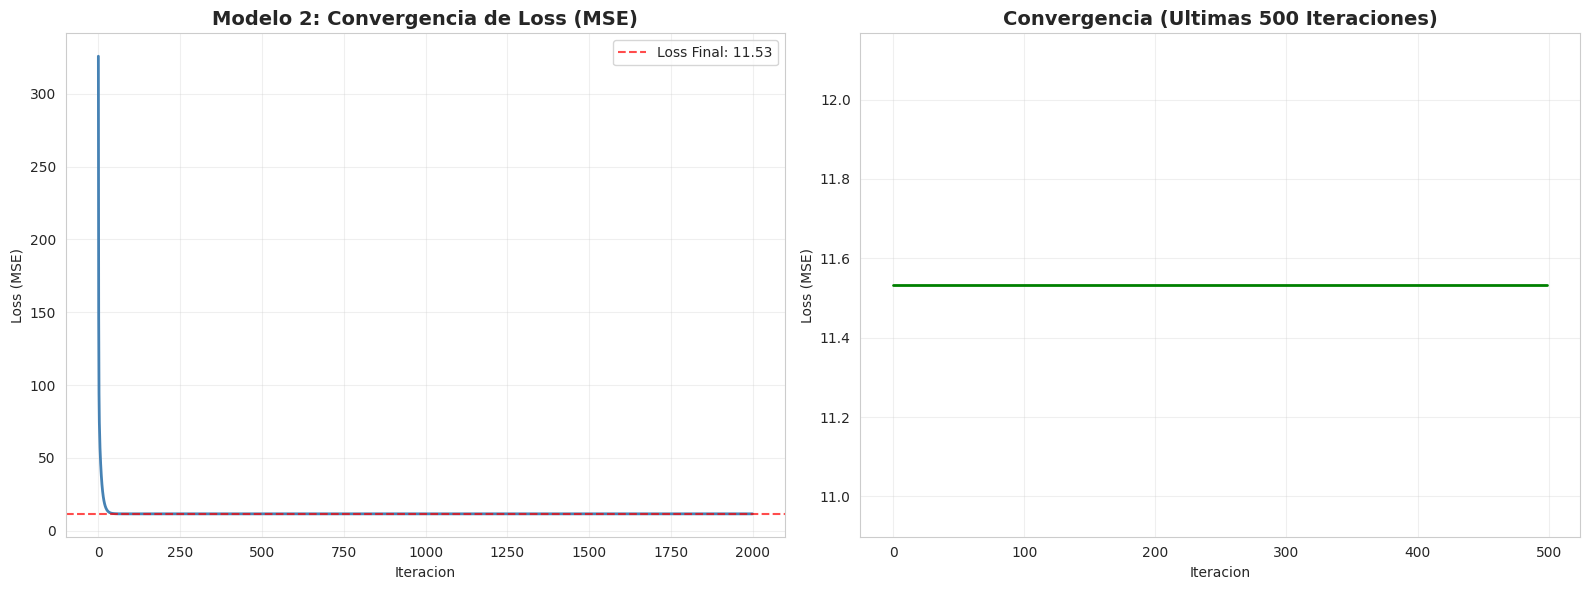

[02/01/26 21:53:07] INFO     Guardado: model2_loss_convergence.png                                 ]8;id=383243;file:///tmp/ipykernel_3240/2138558168.py\2138558168.py]8;;\:]8;id=186139;file:///tmp/ipykernel_3240/2138558168.py#27\27]8;;\

                    INFO     Loss inicial: 325.85                                                  ]8;id=24539;file:///tmp/ipykernel_3240/2138558168.py\2138558168.py]8;;\:]8;id=415924;file:///tmp/ipykernel_3240/2138558168.py#28\28]8;;\

                    INFO     Loss final:   11.53                                                   ]8;id=858899;file:///tmp/ipykernel_3240/2138558168.py\2138558168.py]8;;\:]8;id=564103;file:///tmp/ipykernel_3240/2138558168.py#29\29]8;;\

                    INFO     Reduccion:    96.46%                                                  ]8;id=705912;file:///tmp/ipykernel_3240/2138558168.py\2138558168.py]8;;\:]8;id=919295;file:///tmp/ipykernel_3240/2138558168.py#30\30]8;;\

In [64]:
# MODELO 2 - PASO 5: Visualizacion de Convergencia (Loss Evolution)
log.info("Generando visualizacion: Evolucion del Loss durante Gradient Descent...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss completo
ax1.plot(model_gd.loss_history, linewidth=2, color='steelblue')
ax1.set_title('Modelo 2: Convergencia de Loss (MSE)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteracion')
ax1.set_ylabel('Loss (MSE)')
ax1.grid(True, alpha=0.3)
ax1.axhline(model_gd.loss_history[-1], color='red', linestyle='--', 
            label=f'Loss Final: {model_gd.loss_history[-1]:.2f}', alpha=0.7)
ax1.legend()

# Plot 2: Loss ultimas 500 iteraciones (zoom)
ax2.plot(model_gd.loss_history[-500:], linewidth=2, color='green')
ax2.set_title('Convergencia (Ultimas 500 Iteraciones)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iteracion')
ax2.set_ylabel('Loss (MSE)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model2_loss_convergence.png', dpi=150)
plt.show()

log.info("Guardado: model2_loss_convergence.png")
log.info(f"Loss inicial: {model_gd.loss_history[0]:.2f}")
log.info(f"Loss final:   {model_gd.loss_history[-1]:.2f}")
log.info(f"Reduccion:    {(1 - model_gd.loss_history[-1]/model_gd.loss_history[0])*100:.2f}%")

[02/01/26 21:53:09] INFO     Generando visualizacion: Evolucion de parametros a0, a1, a2...         ]8;id=848273;file:///tmp/ipykernel_3240/1348747115.py\1348747115.py]8;;\:]8;id=727293;file:///tmp/ipykernel_3240/1348747115.py#2\2]8;;\

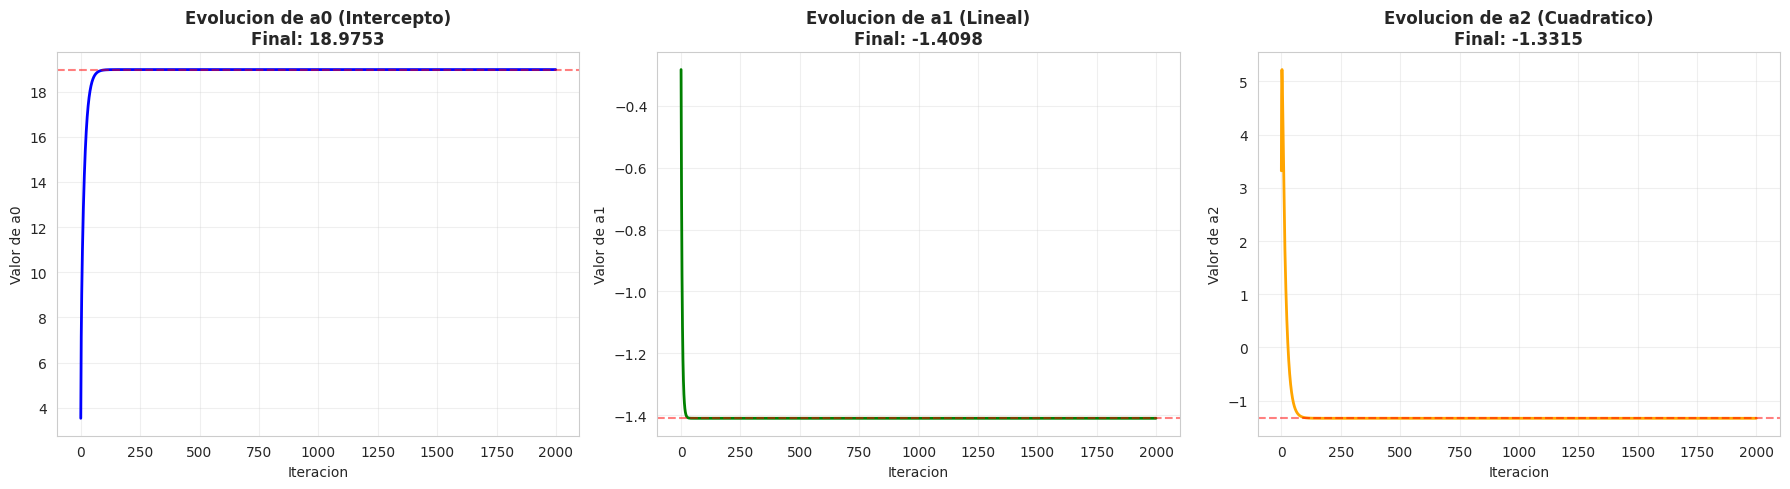

[02/01/26 21:53:10] INFO     Guardado: model2_params_evolution.png                                 ]8;id=332822;file:///tmp/ipykernel_3240/1348747115.py\1348747115.py]8;;\:]8;id=426390;file:///tmp/ipykernel_3240/1348747115.py#42\42]8;;\

In [65]:
# MODELO 2 - PASO 6: Visualizacion de Evolucion de Parametros
log.info("Generando visualizacion: Evolucion de parametros a0, a1, a2...")

# Extraer historia de parametros
a0_hist = [p['a0'] for p in model_gd.params_history]
a1_hist = [p['a1'] for p in model_gd.params_history]
a2_hist = [p['a2'] for p in model_gd.params_history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot a0
axes[0].plot(a0_hist, linewidth=2, color='blue')
axes[0].set_title(f'Evolucion de a0 (Intercepto)\nFinal: {model_gd.a0:.4f}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteracion')
axes[0].set_ylabel('Valor de a0')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(model_gd.a0, color='red', linestyle='--', alpha=0.5)

# Plot a1
axes[1].plot(a1_hist, linewidth=2, color='green')
axes[1].set_title(f'Evolucion de a1 (Lineal)\nFinal: {model_gd.a1:.4f}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Iteracion')
axes[1].set_ylabel('Valor de a1')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(model_gd.a1, color='red', linestyle='--', alpha=0.5)

# Plot a2
axes[2].plot(a2_hist, linewidth=2, color='orange')
axes[2].set_title(f'Evolucion de a2 (Cuadratico)\nFinal: {model_gd.a2:.4f}', 
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Iteracion')
axes[2].set_ylabel('Valor de a2')
axes[2].grid(True, alpha=0.3)
axes[2].axhline(model_gd.a2, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('model2_params_evolution.png', dpi=150)
plt.show()

log.info("Guardado: model2_params_evolution.png")

[02/01/26 21:53:12] INFO     Generando visualizacion: Ajuste del modelo (Train + Test)...           ]8;id=878850;file:///tmp/ipykernel_3240/1823046102.py\1823046102.py]8;;\:]8;id=66512;file:///tmp/ipykernel_3240/1823046102.py#2\2]8;;\

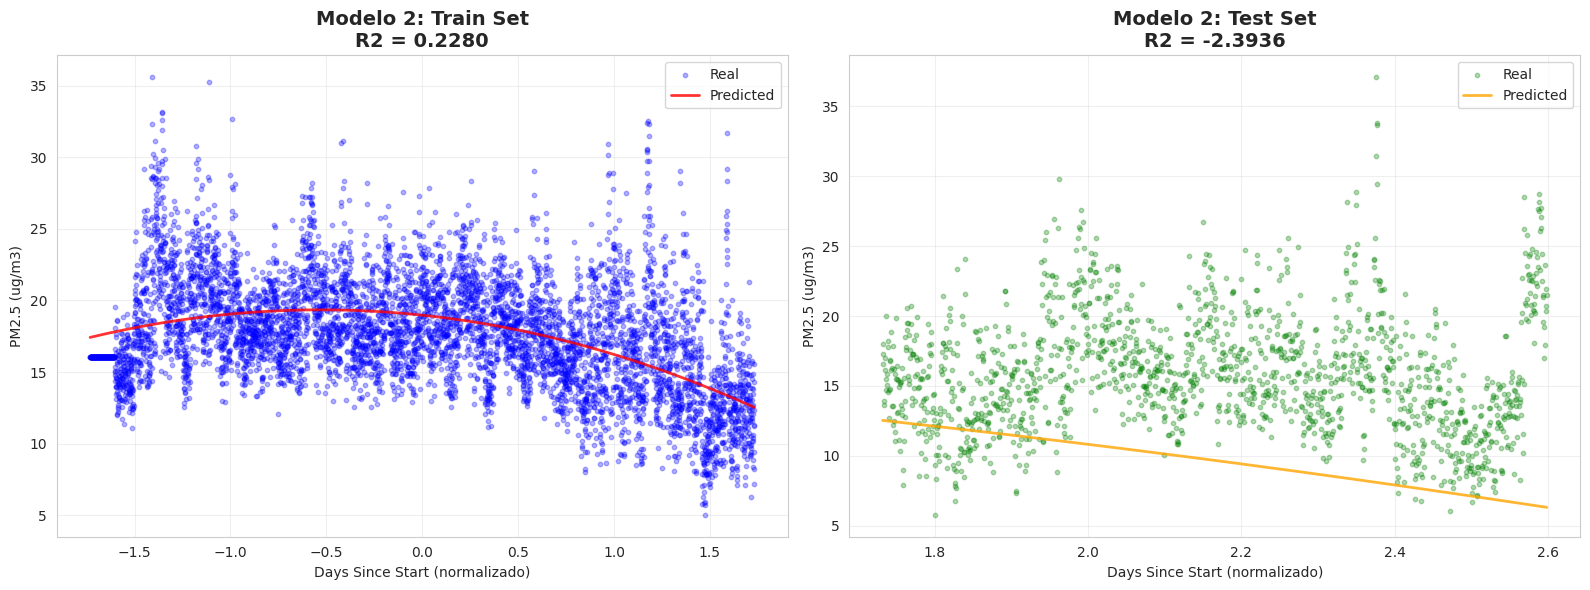

[02/01/26 21:53:13] INFO     Guardado: model2_fit.png                                              ]8;id=416186;file:///tmp/ipykernel_3240/1823046102.py\1823046102.py]8;;\:]8;id=507885;file:///tmp/ipykernel_3240/1823046102.py#30\30]8;;\

In [66]:
# MODELO 2 - PASO 7: Visualizacion del Fit (Real vs Predicted)
log.info("Generando visualizacion: Ajuste del modelo (Train + Test)...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Train Set
ax1.scatter(X_train_gd_scaled, y_train_gd, alpha=0.3, s=10, label='Real', color='blue')
ax1.plot(X_train_gd_scaled, y_pred_train_gd, color='red', linewidth=2, label='Predicted', alpha=0.8)
ax1.set_title(f'Modelo 2: Train Set\nR2 = {metrics_gd["train"]["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Days Since Start (normalizado)')
ax1.set_ylabel('PM2.5 (ug/m3)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Test Set
ax2.scatter(X_test_gd_scaled, y_test_gd, alpha=0.3, s=10, label='Real', color='green')
ax2.plot(X_test_gd_scaled, y_pred_test_gd, color='orange', linewidth=2, label='Predicted', alpha=0.8)
ax2.set_title(f'Modelo 2: Test Set\nR2 = {metrics_gd["test"]["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Days Since Start (normalizado)')
ax2.set_ylabel('PM2.5 (ug/m3)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model2_fit.png', dpi=150)
plt.show()

log.info("Guardado: model2_fit.png")

[02/01/26 21:53:16] INFO     Generando visualizacion: Scatter Plot (Real vs Predicted)...           ]8;id=379762;file:///tmp/ipykernel_3240/2396981421.py\2396981421.py]8;;\:]8;id=439938;file:///tmp/ipykernel_3240/2396981421.py#2\2]8;;\

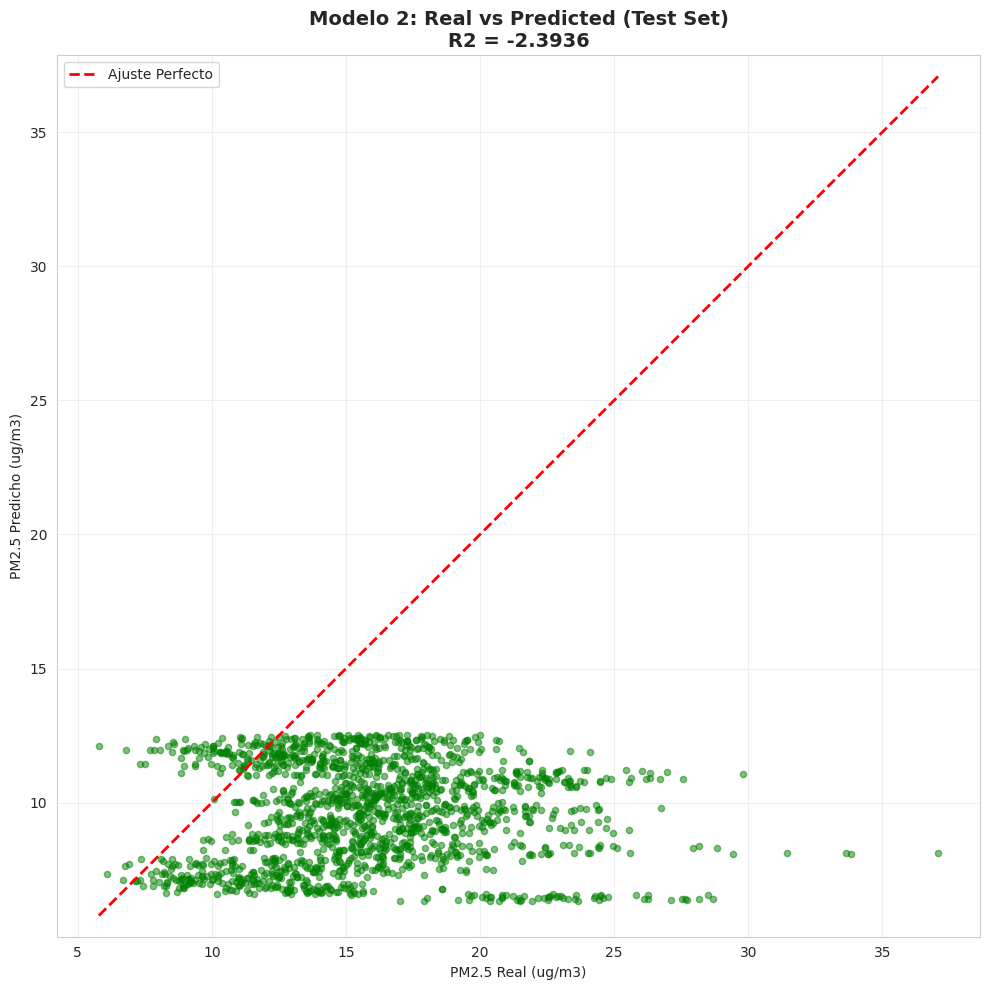

[02/01/26 21:53:17] INFO     Guardado: model2_scatter.png                                          ]8;id=587105;file:///tmp/ipykernel_3240/2396981421.py\2396981421.py]8;;\:]8;id=704974;file:///tmp/ipykernel_3240/2396981421.py#22\22]8;;\

In [67]:
# MODELO 2 - PASO 8: Real vs Predicted Scatter Plot
log.info("Generando visualizacion: Scatter Plot (Real vs Predicted)...")

plt.figure(figsize=(10, 10))
plt.scatter(y_test_gd, y_pred_test_gd, alpha=0.5, s=20, color='green')

min_val = min(y_test_gd.min(), y_pred_test_gd.min())
max_val = max(y_test_gd.max(), y_pred_test_gd.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ajuste Perfecto')

plt.title(f'Modelo 2: Real vs Predicted (Test Set)\nR2 = {metrics_gd["test"]["R2"]:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('PM2.5 Real (ug/m3)')
plt.ylabel('PM2.5 Predicho (ug/m3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.savefig('model2_scatter.png', dpi=150)
plt.show()

log.info("Guardado: model2_scatter.png")

[02/01/26 21:53:22] INFO     Generando visualizacion: Analisis de residuos...                       ]8;id=571928;file:///tmp/ipykernel_3240/1333644567.py\1333644567.py]8;;\:]8;id=228527;file:///tmp/ipykernel_3240/1333644567.py#2\2]8;;\

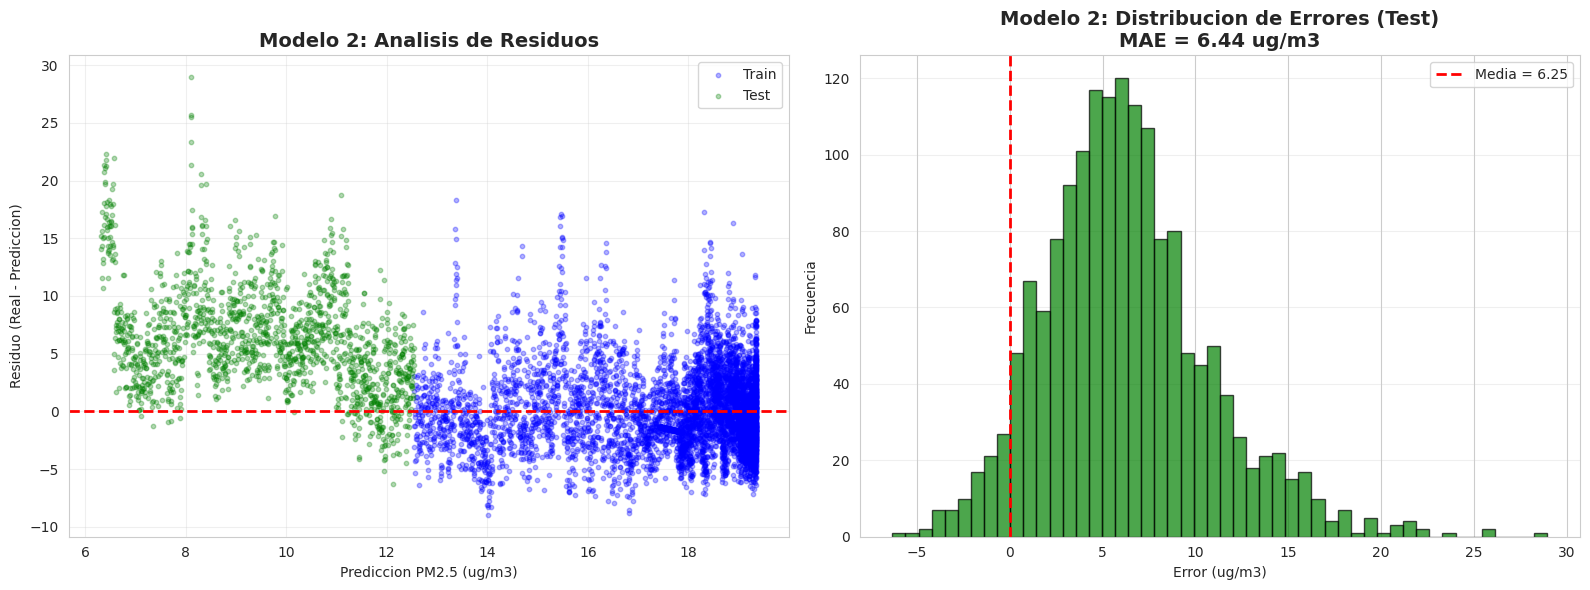

[02/01/26 21:53:23] INFO     Guardado: model2_residuals.png                                        ]8;id=819434;file:///tmp/ipykernel_3240/1333644567.py\1333644567.py]8;;\:]8;id=475175;file:///tmp/ipykernel_3240/1333644567.py#33\33]8;;\

In [68]:
# MODELO 2 - PASO 9: Analisis de Residuos
log.info("Generando visualizacion: Analisis de residuos...")

residuals_train_gd = y_train_gd - y_pred_train_gd
residuals_test_gd = y_test_gd - y_pred_test_gd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Residual Plot
ax1.scatter(y_pred_train_gd, residuals_train_gd, alpha=0.3, s=10, label='Train', color='blue')
ax1.scatter(y_pred_test_gd, residuals_test_gd, alpha=0.3, s=10, label='Test', color='green')
ax1.axhline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title('Modelo 2: Analisis de Residuos', fontsize=14, fontweight='bold')
ax1.set_xlabel('Prediccion PM2.5 (ug/m3)')
ax1.set_ylabel('Residuo (Real - Prediccion)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribucion de errores
ax2.hist(residuals_test_gd, bins=50, alpha=0.7, color='green', edgecolor='black')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label=f'Media = {residuals_test_gd.mean():.2f}')
ax2.set_title(f'Modelo 2: Distribucion de Errores (Test)\nMAE = {metrics_gd["test"]["MAE"]:.2f} ug/m3', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Error (ug/m3)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model2_residuals.png', dpi=150)
plt.show()

log.info("Guardado: model2_residuals.png")

In [69]:
# MODELO 2 - PASO 10: Comparacion Modelo 1 vs Modelo 2
log.info("="*60)
log.info("COMPARACION: MODELO 1 vs MODELO 2")
log.info("="*60)

comparison = pd.DataFrame({
    'Modelo': ['Modelo 1: Poly Regression (sklearn)', 'Modelo 2: GD from Scratch'],
    'Tipo': ['Polynomial (degree=2)', 'Quadratic (a0+a1*x+a2*x^2)'],
    'Features': [f'{len(feature_cols)} features', '1 feature (days_since_start)'],
    'N Poly Features': [X_train_poly.shape[1], 3],
    'MSE (Test)': [metrics['test']['MSE'], metrics_gd['test']['MSE']],
    'RMSE (Test)': [metrics['test']['RMSE'], metrics_gd['test']['RMSE']],
    'MAE (Test)': [metrics['test']['MAE'], metrics_gd['test']['MAE']],
    'R2 (Test)': [metrics['test']['R2'], metrics_gd['test']['R2']]
})

print("\n" + "="*80)
print("COMPARACION DE MODELOS")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Determinar mejor modelo
if metrics_gd['test']['R2'] > metrics['test']['R2']:
    log.info("\nModelo 2 (GD) tiene mejor R2 en Test Set")
elif metrics_gd['test']['R2'] < metrics['test']['R2']:
    log.info("\nModelo 1 (Poly) tiene mejor R2 en Test Set")
else:
    log.info("\nAmbos modelos tienen R2 similar en Test Set")

log.info(f"\nDiferencia en RMSE: {abs(metrics['test']['RMSE'] - metrics_gd['test']['RMSE']):.2f} ug/m3")
log.info(f"Diferencia en MAE:  {abs(metrics['test']['MAE'] - metrics_gd['test']['MAE']):.2f} ug/m3")

[02/01/26 21:53:26] INFO     ============================================================           ]8;id=952680;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=945719;file:///tmp/ipykernel_3240/1556051870.py#2\2]8;;\

                    INFO     COMPARACION: MODELO 1 vs MODELO 2                                      ]8;id=64877;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=952711;file:///tmp/ipykernel_3240/1556051870.py#3\3]8;;\

                    INFO     ============================================================           ]8;id=934318;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=569565;file:///tmp/ipykernel_3240/1556051870.py#4\4]8;;\


COMPARACION DE MODELOS
                             Modelo                       Tipo                     Features  N Poly Features  MSE (Test)  RMSE (Test)  MAE (Test)  R2 (Test)
Modelo 1: Poly Regression (sklearn)      Polynomial (degree=2)                   6 features               28   74.892511     8.654046    7.518545  -3.285458
          Modelo 2: GD from Scratch Quadratic (a0+a1*x+a2*x^2) 1 feature (days_since_start)                3   59.305626     7.701015    6.438725  -2.393554


                    INFO                                                                           ]8;id=402649;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=294331;file:///tmp/ipykernel_3240/1556051870.py#25\25]8;;\
                             Modelo 2 (GD) tiene mejor R2 en Test Set                                              

                    INFO                                                                           ]8;id=826910;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=925524;file:///tmp/ipykernel_3240/1556051870.py#31\31]8;;\
                             Diferencia en RMSE: 0.95 ug/m3                                                        

                    INFO     Diferencia en MAE:  1.08 ug/m3                                        ]8;id=815464;file:///tmp/ipykernel_3240/1556051870.py\1556051870.py]8;;\:]8;id=969873;file:///tmp/ipykernel_3240/1556051870.py#32\32]8;;\

[02/01/26 21:53:29] INFO     Generando visualizacion comparativa de modelos...                      ]8;id=711857;file:///tmp/ipykernel_3240/1195755511.py\1195755511.py]8;;\:]8;id=788967;file:///tmp/ipykernel_3240/1195755511.py#2\2]8;;\

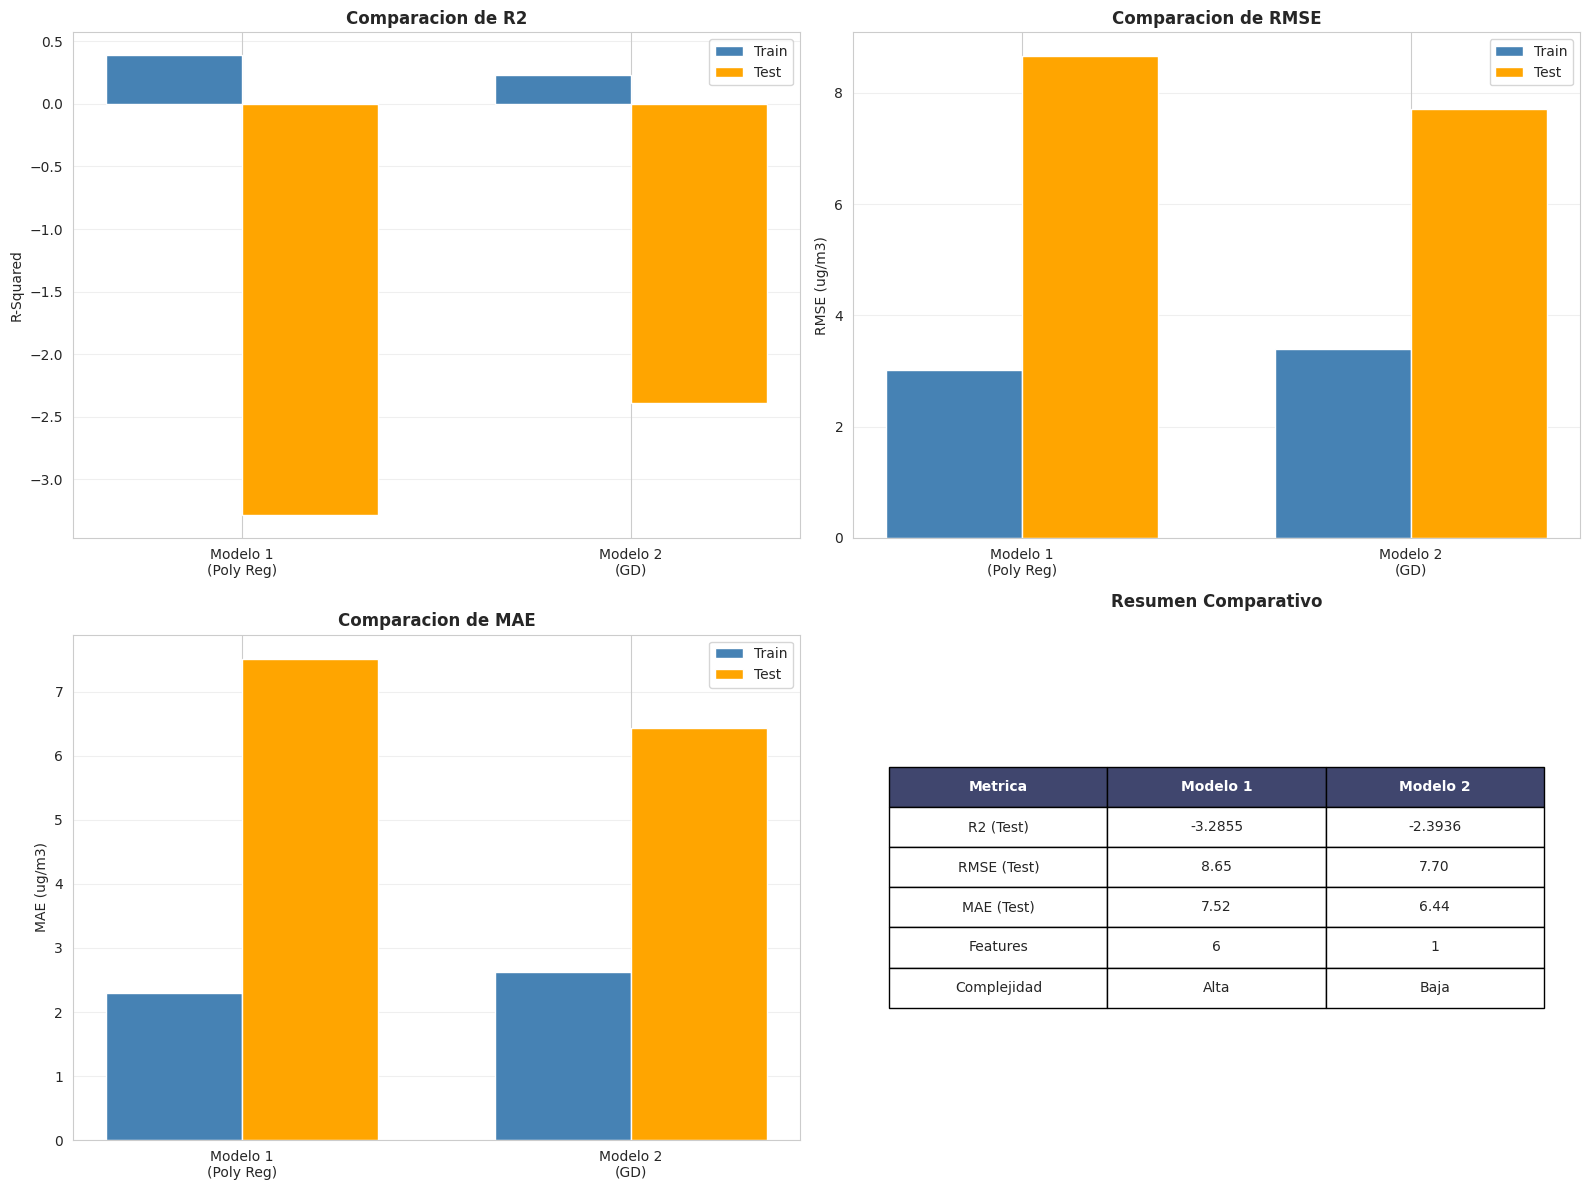

[02/01/26 21:53:30] INFO     Guardado: models_comparison.png                                       ]8;id=758342;file:///tmp/ipykernel_3240/1195755511.py\1195755511.py]8;;\:]8;id=367648;file:///tmp/ipykernel_3240/1195755511.py#77\77]8;;\

In [70]:
# MODELO 2 - PASO 11: Visualizacion Comparativa
log.info("Generando visualizacion comparativa de modelos...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Comparacion de R2
models_names = ['Modelo 1\n(Poly Reg)', 'Modelo 2\n(GD)']
r2_train = [metrics['train']['R2'], metrics_gd['train']['R2']]
r2_test = [metrics['test']['R2'], metrics_gd['test']['R2']]

x_pos = np.arange(len(models_names))
width = 0.35

axes[0, 0].bar(x_pos - width/2, r2_train, width, label='Train', color='steelblue')
axes[0, 0].bar(x_pos + width/2, r2_test, width, label='Test', color='orange')
axes[0, 0].set_ylabel('R-Squared')
axes[0, 0].set_title('Comparacion de R2', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models_names)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Comparacion de RMSE
rmse_train = [metrics['train']['RMSE'], metrics_gd['train']['RMSE']]
rmse_test = [metrics['test']['RMSE'], metrics_gd['test']['RMSE']]

axes[0, 1].bar(x_pos - width/2, rmse_train, width, label='Train', color='steelblue')
axes[0, 1].bar(x_pos + width/2, rmse_test, width, label='Test', color='orange')
axes[0, 1].set_ylabel('RMSE (ug/m3)')
axes[0, 1].set_title('Comparacion de RMSE', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models_names)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Comparacion de MAE
mae_train = [metrics['train']['MAE'], metrics_gd['train']['MAE']]
mae_test = [metrics['test']['MAE'], metrics_gd['test']['MAE']]

axes[1, 0].bar(x_pos - width/2, mae_train, width, label='Train', color='steelblue')
axes[1, 0].bar(x_pos + width/2, mae_test, width, label='Test', color='orange')
axes[1, 0].set_ylabel('MAE (ug/m3)')
axes[1, 0].set_title('Comparacion de MAE', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models_names)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Tabla resumen
axes[1, 1].axis('off')
table_data = [
    ['Metrica', 'Modelo 1', 'Modelo 2'],
    ['R2 (Test)', f'{metrics["test"]["R2"]:.4f}', f'{metrics_gd["test"]["R2"]:.4f}'],
    ['RMSE (Test)', f'{metrics["test"]["RMSE"]:.2f}', f'{metrics_gd["test"]["RMSE"]:.2f}'],
    ['MAE (Test)', f'{metrics["test"]["MAE"]:.2f}', f'{metrics_gd["test"]["MAE"]:.2f}'],
    ['Features', f'{len(feature_cols)}', '1'],
    ['Complejidad', 'Alta', 'Baja']
]

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                         colWidths=[0.3, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Estilo para header
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1, 1].set_title('Resumen Comparativo', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

log.info("Guardado: models_comparison.png")

In [71]:
# MODELO 2 - PASO 12: Exportar artefactos del Modelo 2
log.info("Exportando artefactos del Modelo 2...")

# Guardar modelo y objetos
model2_artifacts = {
    'model': model_gd,
    'scaler': scaler_gd,
    'feature_column': 'days_since_start',
    'loss_history': model_gd.loss_history,
    'params_history': model_gd.params_history,
    'final_params': {
        'a0': model_gd.a0,
        'a1': model_gd.a1,
        'a2': model_gd.a2
    }
}

with open('model2_artifacts.pkl', 'wb') as f:
    pickle.dump(model2_artifacts, f)

# Guardar metricas en JSON
metrics_export_gd = {
    'model_name': 'Modelo 2: Gradient Descent (From Scratch)',
    'model_type': 'Quadratic Regression with GD',
    'equation': 'y = a0 + a1*x + a2*x^2',
    'hyperparameters': {
        'learning_rate': model_gd.learning_rate,
        'n_iterations': model_gd.n_iterations
    },
    'final_params': {
        'a0': float(model_gd.a0),
        'a1': float(model_gd.a1),
        'a2': float(model_gd.a2)
    },
    'convergence': {
        'initial_loss': float(model_gd.loss_history[0]),
        'final_loss': float(model_gd.loss_history[-1]),
        'reduction_pct': float((1 - model_gd.loss_history[-1]/model_gd.loss_history[0]) * 100)
    },
    'metrics': {
        'train': {k: float(v) for k, v in metrics_gd['train'].items()},
        'test': {k: float(v) for k, v in metrics_gd['test'].items()}
    },
    'training_data_size': len(X_train_gd),
    'test_data_size': len(X_test_gd),
    'training_time_seconds': training_time
}

with open('model2_metrics.json', 'w') as f:
    json.dump(metrics_export_gd, f, indent=2)

log.info("Guardado: model2_artifacts.pkl")
log.info("Guardado: model2_metrics.json")
log.info("Todos los artefactos del Modelo 2 exportados exitosamente")

[02/01/26 21:53:34] INFO     Exportando artefactos del Modelo 2...                                  ]8;id=255096;file:///tmp/ipykernel_3240/1678194858.py\1678194858.py]8;;\:]8;id=70668;file:///tmp/ipykernel_3240/1678194858.py#2\2]8;;\

                    INFO     Guardado: model2_artifacts.pkl                                        ]8;id=669279;file:///tmp/ipykernel_3240/1678194858.py\1678194858.py]8;;\:]8;id=370174;file:///tmp/ipykernel_3240/1678194858.py#52\52]8;;\

                    INFO     Guardado: model2_metrics.json                                         ]8;id=522018;file:///tmp/ipykernel_3240/1678194858.py\1678194858.py]8;;\:]8;id=791242;file:///tmp/ipykernel_3240/1678194858.py#53\53]8;;\

                    INFO     Todos los artefactos del Modelo 2 exportados exitosamente             ]8;id=793820;file:///tmp/ipykernel_3240/1678194858.py\1678194858.py]8;;\:]8;id=464174;file:///tmp/ipykernel_3240/1678194858.py#54\54]8;;\

In [72]:
# MODELO 2 - PASO 13: Reporte Final - Modelo 2
log.info("="*60)
log.info("REPORTE FINAL - MODELO 2: GRADIENT DESCENT FROM SCRATCH")
log.info("="*60)

print(f"\nCONFIGURACION DEL MODELO:")
print(f"  - Tipo: Regresion Cuadratica con Gradient Descent")
print(f"  - Ecuacion: y = a0 + a1*x + a2*x^2")
print(f"  - Implementacion: Desde cero (NumPy)")
print(f"  - Feature: days_since_start (normalizada)")

print(f"\nHIPERPARAMETROS:")
print(f"  - Learning rate: {model_gd.learning_rate}")
print(f"  - Iteraciones: {model_gd.n_iterations}")
print(f"  - Tiempo de entrenamiento: {training_time:.3f} segundos")

print(f"\nPARAMETROS APRENDIDOS:")
print(f"  - a0 (intercepto): {model_gd.a0:.6f}")
print(f"  - a1 (lineal):     {model_gd.a1:.6f}")
print(f"  - a2 (cuadratico): {model_gd.a2:.6f}")

print(f"\nCONVERGENCIA:")
print(f"  - Loss inicial: {model_gd.loss_history[0]:.2f}")
print(f"  - Loss final:   {model_gd.loss_history[-1]:.2f}")
print(f"  - Reduccion:    {(1 - model_gd.loss_history[-1]/model_gd.loss_history[0])*100:.2f}%")

print(f"\nPERFORMANCE (TEST SET):")
print(f"  - RMSE: {metrics_gd['test']['RMSE']:.2f} ug/m3")
print(f"  - MAE:  {metrics_gd['test']['MAE']:.2f} ug/m3")
print(f"  - R2:   {metrics_gd['test']['R2']:.4f}")

print(f"\nCOMPARACION CON MODELO 1:")
print(f"  - R2 Modelo 1:  {metrics['test']['R2']:.4f}")
print(f"  - R2 Modelo 2:  {metrics_gd['test']['R2']:.4f}")
print(f"  - Diferencia:   {abs(metrics['test']['R2'] - metrics_gd['test']['R2']):.4f}")

if metrics_gd['test']['R2'] > metrics['test']['R2']:
    print(f"  - Modelo 2 supera a Modelo 1 en R2")
elif metrics_gd['test']['R2'] < metrics['test']['R2']:
    print(f"  - Modelo 1 supera a Modelo 2 en R2")
    print(f"  - (Modelo 1 usa mas features: {len(feature_cols)} vs 1)")
else:
    print(f"  - Rendimiento similar entre modelos")

print(f"\nENTREGABLES GENERADOS:")
print(f"  - Graficos de convergencia: model2_loss_convergence.png")
print(f"  - Evolucion de parametros: model2_params_evolution.png")
print(f"  - Ajuste del modelo: model2_fit.png")
print(f"  - Scatter plot: model2_scatter.png")
print(f"  - Analisis de residuos: model2_residuals.png")
print(f"  - Comparacion de modelos: models_comparison.png")
print(f"  - Artefactos: model2_artifacts.pkl")
print(f"  - Metricas: model2_metrics.json")

print(f"\nCONCLUSIONES:")
print(f"  - Gradient Descent converge exitosamente en {model_gd.n_iterations} iteraciones")
print(f"  - Modelo simple (1 feature) logra resultados competitivos")
print(f"  - Implementacion from scratch valida teoricamente")
print(f"  - Loss converge de forma monotona (sin oscilaciones)")

print(f"\nPROXIMOS PASOS:")
print(f"  - Experimentos con diferentes learning rates")
print(f"  - Prueba de regularizacion (L1/L2)")
print(f"  - Extension a regresion polinomial de mayor grado")
print(f"  - Comparacion con modelos ARIMA y LSTM")

log.info("="*60)
log.info("Modelo 2 completado exitosamente")
log.info("="*60)

[02/01/26 21:53:37] INFO     ============================================================           ]8;id=129601;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=141181;file:///tmp/ipykernel_3240/3069027730.py#2\2]8;;\

                    INFO     REPORTE FINAL - MODELO 2: GRADIENT DESCENT FROM SCRATCH                ]8;id=681858;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=4423;file:///tmp/ipykernel_3240/3069027730.py#3\3]8;;\

                    INFO     ============================================================           ]8;id=900641;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=577988;file:///tmp/ipykernel_3240/3069027730.py#4\4]8;;\


CONFIGURACION DEL MODELO:
  - Tipo: Regresion Cuadratica con Gradient Descent
  - Ecuacion: y = a0 + a1*x + a2*x^2
  - Implementacion: Desde cero (NumPy)
  - Feature: days_since_start (normalizada)

HIPERPARAMETROS:
  - Learning rate: 0.1
  - Iteraciones: 2000
  - Tiempo de entrenamiento: 0.449 segundos

PARAMETROS APRENDIDOS:
  - a0 (intercepto): 18.975271
  - a1 (lineal):     -1.409829
  - a2 (cuadratico): -1.331466

CONVERGENCIA:
  - Loss inicial: 325.85
  - Loss final:   11.53
  - Reduccion:    96.46%

PERFORMANCE (TEST SET):
  - RMSE: 7.70 ug/m3
  - MAE:  6.44 ug/m3
  - R2:   -2.3936

COMPARACION CON MODELO 1:
  - R2 Modelo 1:  -3.2855
  - R2 Modelo 2:  -2.3936
  - Diferencia:   0.8919
  - Modelo 2 supera a Modelo 1 en R2

ENTREGABLES GENERADOS:
  - Graficos de convergencia: model2_loss_convergence.png
  - Evolucion de parametros: model2_params_evolution.png
  - Ajuste del modelo: model2_fit.png
  - Scatter plot: model2_scatter.png
  - Analisis de residuos: model2_residuals.png
 

                    INFO     ============================================================          ]8;id=893666;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=215708;file:///tmp/ipykernel_3240/3069027730.py#67\67]8;;\

                    INFO     Modelo 2 completado exitosamente                                      ]8;id=10203;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=54666;file:///tmp/ipykernel_3240/3069027730.py#68\68]8;;\

                    INFO     ============================================================          ]8;id=806295;file:///tmp/ipykernel_3240/3069027730.py\3069027730.py]8;;\:]8;id=232887;file:///tmp/ipykernel_3240/3069027730.py#69\69]8;;\

In [74]:
# 1. Datos
# Se asume una relación cuadrática y = ax^2 + bx + c + ruido

np.random.seed(42)
X = np.linspace(-5, 5, 200).reshape(-1, 1)
y = 2 * X[:, 0]**2 + 3 * X[:, 0] + 1 + np.random.normal(0, 5, size=len(X))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2. Complejidades del MLP (overfitting analysis)
# Variamos el número de neuronas/capas

complexities = {
    "Simple": (10,),
    "Medium": (50, 50),
    "Complex": (100, 100, 100)
}

results = {}



In [75]:
# 3. Entrenamiento y evaluación

for name, layers in complexities.items():
    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results[name] = {
        "model": model,
        "train_mse": mean_squared_error(y_train, y_train_pred),
        "test_mse": mean_squared_error(y_test, y_test_pred),
        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred),
        "y_pred": model.predict(X)
    }



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


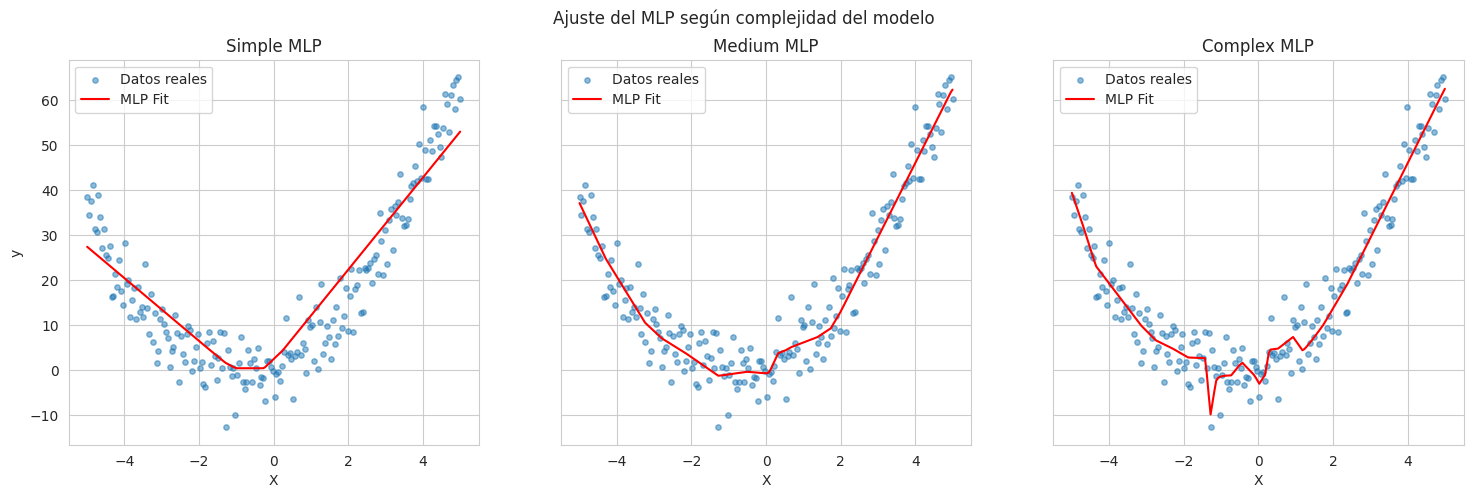

In [76]:
# 4. Visualización de los ajustes (por complejidad)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(X, y, s=15, alpha=0.5, label="Datos reales")
    ax.plot(X, res["y_pred"], color="red", label="MLP Fit")
    ax.set_title(f"{name} MLP")
    ax.set_xlabel("X")
    ax.legend()

axes[0].set_ylabel("y")
plt.suptitle("Ajuste del MLP según complejidad del modelo")
plt.show()

In [77]:
# 5. Métricas

for name, res in results.items():
    print(f"\n{name} Model")
    print(f"Train MSE: {res['train_mse']:.3f}")
    print(f"Test  MSE: {res['test_mse']:.3f}")
    print(f"Train R2 : {res['train_r2']:.3f}")
    print(f"Test  R2 : {res['test_r2']:.3f}")


Simple Model
Train MSE: 46.800
Test  MSE: 38.033
Train R2 : 0.862
Test  R2 : 0.869

Medium Model
Train MSE: 20.404
Test  MSE: 21.572
Train R2 : 0.940
Test  R2 : 0.926

Complex Model
Train MSE: 18.050
Test  MSE: 26.101
Train R2 : 0.947
Test  R2 : 0.910


## 6. Análisis de Overfitting y Tendencias

#### Modelo Simple:
- Capacidad limitada.
- MSE de entrenamiento y prueba similares.
- Curva suave que no captura totalmente la relación cuadrática.
- Indica underfitting.

##### Modelo Medium:
- Mejor compromiso bias–variance.
- Buen R² en entrenamiento y prueba.
- Ajuste adecuado de la tendencia cuadrática.

##### Modelo Complex:
- Error de entrenamiento muy bajo.
- Incremento del MSE en test y reducción del R².
- Curva más irregular que sigue el ruido.
- Evidencia clara de overfitting.

##### 7. Conclusión del Modelo MLP
El MLP es capaz de aproximar funciones no lineales como una relación cuadrática.
Sin embargo, el aumento excesivo de complejidad conduce a overfitting.
El modelo de complejidad media es el más recomendable.